In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("crop_yield_cleaned.csv")

In [3]:
df.head()

,crop,year,season,state,area,annual_rainfall,fertilizer,pesticide,yield
0,Arecanut,1997,Whole Year,Assam,73814.0,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,2051.4,165500.63,539.09,0.420909


In [4]:
df.shape

(19689, 9)

In [5]:
%pip install pandas numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
print(pd.__version__)

3.0.5


In [7]:
df = pd.read_csv("crop_yield_cleaned.csv")

In [8]:
df.head()

,crop,year,season,state,area,annual_rainfall,fertilizer,pesticide,yield
0,Arecanut,1997,Whole Year,Assam,73814.0,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,2051.4,165500.63,539.09,0.420909


In [9]:
df.shape

(19689, 9)

In [10]:
y = df["yield"]

In [11]:
X = df.drop(columns=["yield"])

In [12]:
X.head()

,crop,year,season,state,area,annual_rainfall,fertilizer,pesticide
0,Arecanut,1997,Whole Year,Assam,73814.0,2051.4,7024878.38,22882.34
1,Arhar/Tur,1997,Kharif,Assam,6637.0,2051.4,631643.29,2057.47
2,Castor seed,1997,Kharif,Assam,796.0,2051.4,75755.32,246.76
3,Coconut,1997,Whole Year,Assam,19656.0,2051.4,1870661.52,6093.36
4,Cotton(lint),1997,Kharif,Assam,1739.0,2051.4,165500.63,539.09


In [13]:
y.head()

0       0.796087
1       0.710435
2       0.238333
3    5238.051739
4       0.420909
Name: yield, dtype: float64

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19689, 8)
y shape: (19689,)


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [18]:
categorical_features = ["crop", "season", "state"]

numerical_features = [
    "year",
    "area",
    "annual_rainfall",
    "fertilizer",
    "pesticide"
]

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [20]:
X_train_processed = preprocessor.fit_transform(X_train)

In [21]:
X_test_processed = preprocessor.transform(X_test)

In [22]:
print("Original X_train:", X_train.shape)
print("Processed X_train:", X_train_processed.shape)

print("Original X_test:", X_test.shape)
print("Processed X_test:", X_test_processed.shape)

Original X_train: (15751, 8)
Processed X_train: (15751, 96)
Original X_test: (3938, 8)
Processed X_test: (3938, 96)


In [23]:
print("Processed X_test:", X_test_processed.shape)

Processed X_test: (3938, 96)


In [24]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [25]:
# Make predictions on test data
y_pred = rf_model.predict(X_test_processed)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 3938


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("================================")
print("RANDOM FOREST RESULTS")
print("================================")

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

RANDOM FOREST RESULTS
MAE : 9.540209482518499
RMSE: 126.38478757803703
R²  : 0.9800645034892566


In [27]:
# Compare actual vs predicted values

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(10))

      Actual  Predicted
0   3.820000   4.096153
1   1.395357   1.412093
2   6.522727   6.614651
3   0.812857   0.849733
4   0.508000   0.536378
5   0.358000   0.479199
6   0.749091   0.628154
7   1.835789   2.009914
8  75.314375  78.011640
9   1.775000   1.927500


In [28]:
# Calculate prediction error

results["Error"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = abs(results["Error"])

# Show the 10 biggest errors
largest_errors = results.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

print(largest_errors)

            Actual     Predicted        Error  Absolute_Error
1384  16935.058460  12762.867383  4172.191077     4172.191077
876    9619.110000  12939.980199 -3320.870199     3320.870199
3814  13248.162260  10913.019426  2335.142834     2335.142834
787   16254.000000  14299.871137  1954.128863     1954.128863
1149  13712.573080  11920.041850  1792.531230     1792.531230
2548   8486.539565   6788.765713  1697.773852     1697.773852
2009  11820.710000  10220.882287  1599.827713     1599.827713
2750  11263.830000   9946.091720  1317.738280     1317.738280
2796  13934.122500  12723.168272  1210.954228     1210.954228
762    5238.051739   6429.548701 -1191.496962     1191.496962


In [29]:
from sklearn.ensemble import ExtraTreesRegressor

# Create Extra Trees model
extra_model = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
extra_model.fit(X_train_processed, y_train)

print("Extra Trees model trained successfully!")

Extra Trees model trained successfully!


In [30]:
# Make predictions
extra_pred = extra_model.predict(X_test_processed)

print("Predictions generated successfully!")

Predictions generated successfully!


In [31]:
# Evaluate Extra Trees

extra_mae = mean_absolute_error(y_test, extra_pred)

extra_rmse = np.sqrt(
    mean_squared_error(y_test, extra_pred)
)

extra_r2 = r2_score(y_test, extra_pred)

print("================================")
print("EXTRA TREES RESULTS")
print("================================")

print("MAE :", extra_mae)
print("RMSE:", extra_rmse)
print("R²  :", extra_r2)

EXTRA TREES RESULTS
MAE : 8.65687773245273
RMSE: 134.2788064527722
R²  : 0.977496379483755


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the model
gb_model.fit(X_train_processed, y_train)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [33]:
# Make predictions
gb_pred = gb_model.predict(X_test_processed)

print("Predictions generated successfully!")

Predictions generated successfully!


In [34]:
# Evaluate Gradient Boosting

gb_mae = mean_absolute_error(y_test, gb_pred)

gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_pred)
)

gb_r2 = r2_score(y_test, gb_pred)

print("================================")
print("GRADIENT BOOSTING RESULTS")
print("================================")

print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

GRADIENT BOOSTING RESULTS
MAE : 13.035932149382727
RMSE: 148.7822980131842
R²  : 0.9723726025481512


In [35]:
# Final model comparison

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],
    "MAE": [
        mae,
        extra_mae,
        gb_mae
    ],
    "RMSE": [
        rmse,
        extra_rmse,
        gb_rmse
    ],
    "R2": [
        r2,
        extra_r2,
        gb_r2
    ]
})

print(comparison)

               Model        MAE        RMSE        R2
0      Random Forest   9.540209  126.384788  0.980065
1        Extra Trees   8.656878  134.278806  0.977496
2  Gradient Boosting  13.035932  148.782298  0.972373


In [36]:
# STEP 6: Log-transformed target

from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Transform the target
y_train_log = np.log1p(y_train)

# Create Random Forest
rf_log_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train using transformed target
rf_log_model.fit(X_train_processed, y_train_log)

print("Log-transformed Random Forest trained successfully!")

Log-transformed Random Forest trained successfully!


In [37]:
# Make predictions
y_pred_log = rf_log_model.predict(X_test_processed)

# Convert predictions back to original yield scale
y_pred_log_original = np.expm1(y_pred_log)

print("Predictions generated successfully!")

Predictions generated successfully!


In [38]:
# Evaluate log-transformed Random Forest

log_mae = mean_absolute_error(
    y_test,
    y_pred_log_original
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_original
    )
)

log_r2 = r2_score(
    y_test,
    y_pred_log_original
)

print("================================")
print("LOG RANDOM FOREST RESULTS")
print("================================")

print("MAE :", log_mae)
print("RMSE:", log_rmse)
print("R²  :", log_r2)

LOG RANDOM FOREST RESULTS
MAE : 13.56806541126492
RMSE: 279.37762644703633
R²  : 0.9025861523151691


In [39]:
%pip install matplotlib 

Note: you may need to restart the kernel to use updated packages.


In [40]:
# STEP 7: Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get importance from Random Forest
importances = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

# Show top 15 features
print(feature_importance.head(15))

                              Feature  Importance
9           categorical__crop_Coconut    0.846129
93         remainder__annual_rainfall    0.031852
92                    remainder__area    0.022529
95               remainder__pesticide    0.020863
73       categorical__state_Karnataka    0.019700
94              remainder__fertilizer    0.012958
90     categorical__state_West Bengal    0.012559
63           categorical__state_Assam    0.010878
91                    remainder__year    0.007168
86       categorical__state_Telangana    0.003973
65    categorical__state_Chhattisgarh    0.003741
82      categorical__state_Puducherry    0.002394
61  categorical__state_Andhra Pradesh    0.002332
85      categorical__state_Tamil Nadu    0.001970
67             categorical__state_Goa    0.000489


In [41]:
# Check average yield by crop

crop_yield = df.groupby("crop")["yield"].agg(
    ["count", "mean", "median", "min", "max"]
)

crop_yield = crop_yield.sort_values(
    "mean",
    ascending=False
)

print(crop_yield)

                       count         mean       median       min           max
crop                                                                          
Coconut                  172  8652.000199  8466.315523  0.000000  21105.000000
Sugarcane                605    51.727439    53.158158  0.290000    165.000000
Banana                   245    26.851128    17.948750  0.000000    126.387692
Tapioca                  201    16.667301    11.117778  0.000000     42.097857
Potato                   628    13.331718    10.175284  0.000000    311.020000
Onion                    454    13.247525     9.192846  0.000000    381.420000
Sweet potato             273     9.240788     8.512727  0.000000     26.339444
Jute                     181     7.555393     8.146250  0.000000     25.430556
Ginger                   323     6.442202     4.887500  0.000000     36.357826
Mesta                    210     5.389204     4.935250  0.000000     17.678750
Garlic                   250     4.544886     3.3068

In [42]:
# STEP 7B: Check Coconut prediction performance

test_results = X_test.copy()

test_results["Actual"] = y_test.values
test_results["Predicted"] = y_pred
test_results["Crop"] = test_results["crop"].values

# Coconut only
coconut_results = test_results[
    test_results["Crop"] == "Coconut"
]

coconut_mae = mean_absolute_error(
    coconut_results["Actual"],
    coconut_results["Predicted"]
)

coconut_rmse = np.sqrt(
    mean_squared_error(
        coconut_results["Actual"],
        coconut_results["Predicted"]
    )
)

coconut_r2 = r2_score(
    coconut_results["Actual"],
    coconut_results["Predicted"]
)

print("================================")
print("COCONUT PERFORMANCE")
print("================================")

print("Number of test samples:", len(coconut_results))
print("MAE :", coconut_mae)
print("RMSE:", coconut_rmse)
print("R²  :", coconut_r2)

COCONUT PERFORMANCE
Number of test samples: 34
MAE : 1013.9197679379397
RMSE: 1359.6818851389683
R²  : 0.8971598814348909


In [43]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)

print("================================")
print("PERCENTAGE ERROR")
print("================================")

print("MAPE :", mape)
print("MAPE %:", mape * 100)

PERCENTAGE ERROR
MAPE : 38142048516969.26
MAPE %: 3814204851696926.0


In [44]:
# STEP 8B: Performance by crop

test_results = X_test.copy()

test_results["Actual"] = y_test.values
test_results["Predicted"] = y_pred

crop_metrics = []

for crop_name, group in test_results.groupby("crop"):

    mae_crop = mean_absolute_error(
        group["Actual"],
        group["Predicted"]
    )

    rmse_crop = np.sqrt(
        mean_squared_error(
            group["Actual"],
            group["Predicted"]
        )
    )

    # R² requires at least 2 different actual values
    if len(group) > 1 and group["Actual"].nunique() > 1:
        r2_crop = r2_score(
            group["Actual"],
            group["Predicted"]
        )
    else:
        r2_crop = np.nan

    crop_metrics.append({
        "Crop": crop_name,
        "Samples": len(group),
        "MAE": mae_crop,
        "RMSE": rmse_crop,
        "R2": r2_crop
    })

crop_metrics = pd.DataFrame(crop_metrics)

# Sort by number of samples
crop_metrics = crop_metrics.sort_values(
    "Samples",
    ascending=False
)

print(crop_metrics.to_string(index=False))

                 Crop  Samples         MAE        RMSE           R2
                 Rice      236    0.406463    1.916634    -3.225900
                Maize      197    1.001624    6.862206    -7.893857
                 Urad      161    0.110294    0.212193     0.465141
              Sesamum      150    0.088473    0.142878     0.616056
            Groundnut      147    0.178291    0.264245     0.785576
    Moong(Green Gram)      146    0.083830    0.126147     0.776215
            Sugarcane      112    5.878508    7.982913     0.926160
    Rapeseed &Mustard      111    0.156831    0.378455     0.786665
               Potato      109    2.006126    4.095356     0.458146
            Arhar/Tur      107    0.101709    0.149359     0.726709
                 Gram      103    0.195302    0.671655     0.452683
                Wheat      103    0.302155    0.476747     0.862007
                Jowar      102    0.349551    1.409216    -6.612418
                Bajra       99    0.800247    4.

In [45]:
# STEP 8C: Overall crop-wise performance

# Only include crops with at least 30 test samples
reliable_crops = crop_metrics[
    crop_metrics["Samples"] >= 30
]

print("Number of reliable crops:", len(reliable_crops))

print("\nAverage MAE across crops:")
print(reliable_crops["MAE"].mean())

print("\nAverage RMSE across crops:")
print(reliable_crops["RMSE"].mean())

print("\nAverage R² across crops:")
print(reliable_crops["R2"].mean())

Number of reliable crops: 43

Average MAE across crops:
24.404413123713994

Average RMSE across crops:
33.455930358881666

Average R² across crops:
0.1334765711501101


In [46]:
from sklearn.pipeline import Pipeline

print("Pipeline imported successfully!")

Pipeline imported successfully!


In [47]:
import joblib

# Save the complete preprocessing + Random Forest pipeline
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

# Train final model on all available data
final_model.fit(X, y)

# Save model
joblib.dump(final_model, "crop_yield_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [48]:
print("Minimum year:", X["year"].min())
print("Maximum year:", X["year"].max())

print("\nYears available in dataset:")
print(sorted(X["year"].unique()))

Minimum year: 1997
Maximum year: 2020

Years available in dataset:
[np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [49]:
test_input = pd.DataFrame({
    "crop": ["Rice"] * 4,
    "year": [2010, 2015, 2020, 2030],
    "season": ["Kharif"] * 4,
    "state": ["Punjab"] * 4,
    "area": [100] * 4,
    "annual_rainfall": [800] * 4,
    "fertilizer": [100] * 4,
    "pesticide": [20] * 4
})

predictions = final_model.predict(test_input)

for year, prediction in zip(test_input["year"], predictions):
    print(f"Year {year}: {prediction:.4f}")

Year 2010: 3.3600
Year 2015: 3.5325
Year 2020: 3.5507
Year 2030: 3.5507


In [50]:
test_input = pd.DataFrame({
    "crop": ["Rice"] * 5,
    "year": [2016, 2017, 2018, 2019, 2020],
    "season": ["Kharif"] * 5,
    "state": ["Punjab"] * 5,
    "area": [100] * 5,
    "annual_rainfall": [800] * 5,
    "fertilizer": [100] * 5,
    "pesticide": [20] * 5
})

predictions = final_model.predict(test_input)

for year, prediction in zip(test_input["year"], predictions):
    print(f"Year {year}: {prediction:.4f}")

Year 2016: 3.5487
Year 2017: 3.5534
Year 2018: 3.5534
Year 2019: 3.5507
Year 2020: 3.5507


In [51]:
test_input = pd.DataFrame({
    "crop": ["Rice"] * 5,
    "year": [2021, 2022, 2025, 2028, 2030],
    "season": ["Kharif"] * 5,
    "state": ["Punjab"] * 5,
    "area": [100] * 5,
    "annual_rainfall": [800] * 5,
    "fertilizer": [100] * 5,
    "pesticide": [20] * 5
})

predictions = final_model.predict(test_input)

for year, prediction in zip(test_input["year"], predictions):
    print(f"Year {year}: {prediction:.4f}")

Year 2021: 3.5507
Year 2022: 3.5507
Year 2025: 3.5507
Year 2028: 3.5507
Year 2030: 3.5507


In [52]:
# ============================================
# CHECK CROP-WISE YEARLY YIELD TREND
# ============================================

yearly_crop_yield = (
    pd.DataFrame({
        "crop": X["crop"],
        "year": X["year"],
        "yield": y
    })
    .groupby(["crop", "year"])["yield"]
    .mean()
    .reset_index()
)

print(yearly_crop_yield.head(20))

        crop  year     yield
0   Arecanut  1997  1.234999
1   Arecanut  1998  1.731595
2   Arecanut  1999  1.316106
3   Arecanut  2000  1.554272
4   Arecanut  2001  1.434749
5   Arecanut  2002  1.272126
6   Arecanut  2003  1.110757
7   Arecanut  2004  1.213961
8   Arecanut  2005  2.023793
9   Arecanut  2006  1.237538
10  Arecanut  2007  2.170956
11  Arecanut  2008  1.880274
12  Arecanut  2009  1.876761
13  Arecanut  2010  2.617347
14  Arecanut  2011  2.125696
15  Arecanut  2012  2.670588
16  Arecanut  2013  2.633170
17  Arecanut  2014  2.559816
18  Arecanut  2015  2.699271
19  Arecanut  2016  2.741544


In [53]:
crop_year_counts = (
    yearly_crop_yield
    .groupby("crop")["year"]
    .nunique()
    .sort_values(ascending=False)
)

print(crop_year_counts.head(30))

crop
Arhar/Tur                24
Barley                   24
Garlic                   24
Gram                     24
Groundnut                24
Horse-gram               24
Wheat                    24
Rapeseed &Mustard        24
Rice                     24
Small millets            24
Sesamum                  24
Soyabean                 24
Sugarcane                24
Potato                   24
Ragi                     24
Onion                    24
Other  Rabi pulses       24
Other Kharif pulses      24
Peas & beans (Pulses)    24
Moong(Green Gram)        24
Moth                     24
Masoor                   24
Maize                    24
Tobacco                  24
Turmeric                 24
Urad                     24
Sunflower                24
Arecanut                 23
Cotton(lint)             23
Dry chillies             23
Name: year, dtype: int64


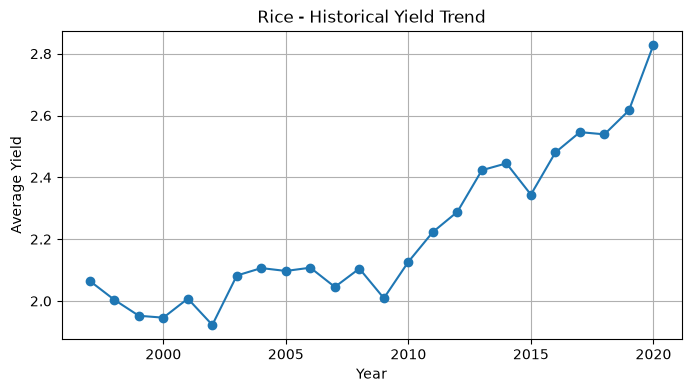

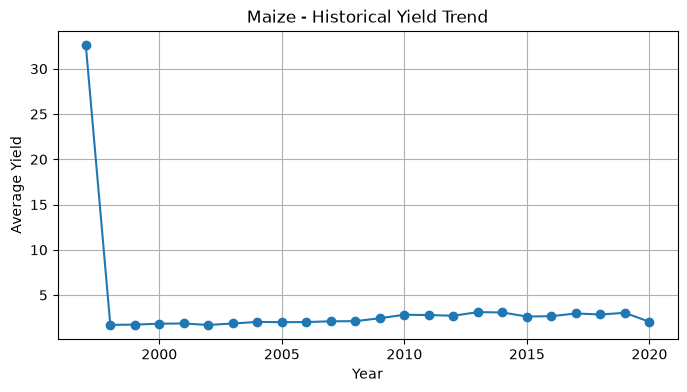

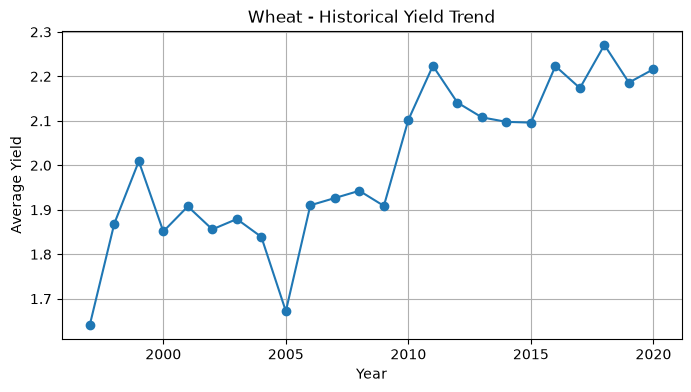

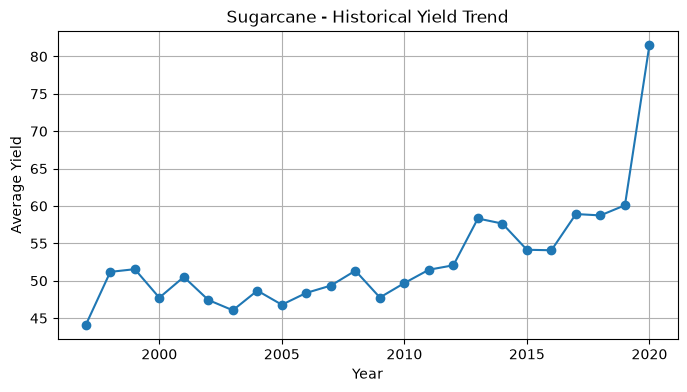

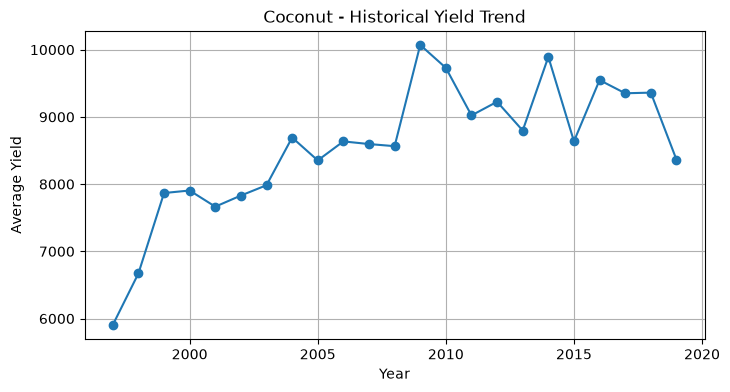

In [54]:
import matplotlib.pyplot as plt

selected_crops = ["Rice", "Maize", "Wheat", "Sugarcane", "Coconut"]

for crop_name in selected_crops:

    crop_data = yearly_crop_yield[
        yearly_crop_yield["crop"] == crop_name
    ]

    plt.figure(figsize=(8, 4))

    plt.plot(
        crop_data["year"],
        crop_data["yield"],
        marker="o"
    )

    plt.title(f"{crop_name} - Historical Yield Trend")
    plt.xlabel("Year")
    plt.ylabel("Average Yield")
    plt.grid(True)

    plt.show()

In [59]:
from sklearn.linear_model import LinearRegression
import pandas as pd

trend_results = []

for crop_name in yearly_crop_yield["crop"].unique():

    crop_data = yearly_crop_yield[
        yearly_crop_yield["crop"] == crop_name
    ].copy()

    # Need at least 5 years of data
    if len(crop_data) >= 5:

        X_time = crop_data[["year"]]
        y_time = crop_data["yield"]

        trend_model = LinearRegression()
        trend_model.fit(X_time, y_time)

        slope = trend_model.coef_[0]
        r2 = trend_model.score(X_time, y_time)

        trend_results.append({
            "crop": crop_name,
            "years": len(crop_data),
            "slope_per_year": slope,
            "trend_r2": r2
        })

trend_results = pd.DataFrame(trend_results)

trend_results = trend_results.sort_values(
    "trend_r2",
    ascending=False
)

print(trend_results.head(20))

                   crop  years  slope_per_year  trend_r2
13         Dry chillies     23        0.132316  0.873727
34  Other Kharif pulses     24        0.019933  0.853142
17            Groundnut     24        0.033533  0.840540
39                 Rice     24        0.031845  0.819858
0              Arecanut     23        0.089877  0.799427
27    Moong(Green Gram)     24        0.011988  0.783332
3                Banana     23        0.748257  0.710804
52                Wheat     24        0.021026  0.710030
50             Turmeric     24        0.120577  0.662846
20                Jowar     23        0.018804  0.659378
23              Linseed     23        0.005752  0.606929
43        Small millets     24        0.020084  0.592241
15               Ginger     23        0.194819  0.573102
9               Coconut     23      110.185967  0.566698
25               Masoor     24        0.009433  0.560805
47         Sweet potato     23        0.162913  0.548580
32   Other  Rabi pulses     24 

In [60]:
# Calculate the average yield for each crop
crop_mean_yield = (
    yearly_crop_yield
    .groupby("crop")["yield"]
    .mean()
    .reset_index(name="mean_yield")
)

# Add average yield to our trend results
trend_results = trend_results.merge(
    crop_mean_yield,
    on="crop",
    how="left"
)

# Calculate percentage change in yield per year
trend_results["relative_slope"] = (
    trend_results["slope_per_year"]
    / trend_results["mean_yield"]
)

# Show the results
trend_results = trend_results.sort_values(
    "trend_r2",
    ascending=False
)

print(
    trend_results[
        [
            "crop",
            "years",
            "mean_yield",
            "slope_per_year",
            "relative_slope",
            "trend_r2"
        ]
    ].head(30)
)

                   crop  years   mean_yield  slope_per_year  relative_slope  \
0          Dry chillies     23     2.014294        0.132316        0.065688   
1   Other Kharif pulses     24     0.693468        0.019933        0.028745   
2             Groundnut     24     1.328047        0.033533        0.025250   
3                  Rice     24     2.221363        0.031845        0.014336   
4              Arecanut     23     2.053571        0.089877        0.043766   
5     Moong(Green Gram)     24     0.528092        0.011988        0.022702   
6                Banana     23    26.683283        0.748257        0.028042   
7                 Wheat     24     2.002142        0.021026        0.010502   
8              Turmeric     24     3.194507        0.120577        0.037745   
9                 Jowar     23     1.065506        0.018804        0.017648   
10              Linseed     23     0.471347        0.005752        0.012202   
11        Small millets     24     0.781234        0

In [61]:
# Time-based train/test split

train_mask = X["year"] <= 2015
test_mask = X["year"] > 2015

X_time_train = X[train_mask].copy()
X_time_test = X[test_mask].copy()

y_time_train = y[train_mask].copy()
y_time_test = y[test_mask].copy()

print("Training years:")
print(X_time_train["year"].min(), "to", X_time_train["year"].max())

print("\nTesting years:")
print(X_time_test["year"].min(), "to", X_time_test["year"].max())

print("\nTraining rows:", len(X_time_train))
print("Testing rows:", len(X_time_test))

Training years:
1997 to 2015

Testing years:
2016 to 2020

Training rows: 15404
Testing rows: 4285


In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features
categorical_features = ["crop", "season", "state"]

numerical_features = [
    "year",
    "area",
    "annual_rainfall",
    "fertilizer",
    "pesticide"
]

# Preprocessing
time_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

# Random Forest
time_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Complete pipeline
time_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", time_preprocessor),
        ("model", time_rf)
    ]
)

# Train ONLY on 1997–2015
time_rf_pipeline.fit(
    X_time_train,
    y_time_train
)

# Predict 2016–2020
time_predictions = time_rf_pipeline.predict(
    X_time_test
)

# Evaluation
time_mae = mean_absolute_error(
    y_time_test,
    time_predictions
)

time_rmse = np.sqrt(
    mean_squared_error(
        y_time_test,
        time_predictions
    )
)

time_r2 = r2_score(
    y_time_test,
    time_predictions
)

print("Time-Based Random Forest Results")
print("---------------------------------")
print(f"MAE  : {time_mae:.4f}")
print(f"RMSE : {time_rmse:.4f}")
print(f"R²   : {time_r2:.4f}")

Time-Based Random Forest Results
---------------------------------
MAE  : 10.7375
RMSE : 145.7797
R²   : 0.9707


In [63]:
from sklearn.linear_model import LinearRegression

# Use only the training period
trend_train_data = pd.DataFrame({
    "crop": X_time_train["crop"].values,
    "year": X_time_train["year"].values,
    "yield": y_time_train.values
})

# Calculate average yield for each crop and year
trend_train_yearly = (
    trend_train_data
    .groupby(["crop", "year"])["yield"]
    .mean()
    .reset_index()
)

# Store one trend model for each crop
crop_trend_models = {}

for crop_name in trend_train_yearly["crop"].unique():

    crop_data = trend_train_yearly[
        trend_train_yearly["crop"] == crop_name
    ].copy()

    if len(crop_data) >= 5:

        model = LinearRegression()

        model.fit(
            crop_data[["year"]],
            crop_data["yield"]
        )

        crop_trend_models[crop_name] = model

print("Number of crop trend models:",
      len(crop_trend_models))

Number of crop trend models: 54


In [64]:
# Create trend predictions for the time-based test period

trend_predictions = []

for index, row in X_time_test.iterrows():

    crop_name = row["crop"]
    year_value = row["year"]

    if crop_name in crop_trend_models:

        trend_model = crop_trend_models[crop_name]

        prediction = trend_model.predict(
            [[year_value]]
        )[0]

    else:
        prediction = np.nan

    trend_predictions.append(prediction)

trend_predictions = np.array(trend_predictions)

# Remove crops where a trend model was unavailable
valid_mask = ~np.isnan(trend_predictions)

trend_actual = y_time_test.values[valid_mask]
trend_predicted = trend_predictions[valid_mask]

# Evaluate the trend model
trend_mae = mean_absolute_error(
    trend_actual,
    trend_predicted
)

trend_rmse = np.sqrt(
    mean_squared_error(
        trend_actual,
        trend_predicted
    )
)

trend_r2 = r2_score(
    trend_actual,
    trend_predicted
)

print("Crop-Specific Time Trend Results")
print("---------------------------------")
print(f"MAE  : {trend_mae:.4f}")
print(f"RMSE : {trend_rmse:.4f}")
print(f"R²   : {trend_r2:.4f}")

c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py

Crop-Specific Time Trend Results
---------------------------------
MAE  : 25.0949
RMSE : 312.4280
R²   : 0.8657


c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py

In [65]:
# Test different weights for Random Forest + Time Trend

rf_test_predictions = time_predictions

# Make sure both arrays use the same valid rows
rf_valid = rf_test_predictions[valid_mask]

weights = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

hybrid_results = []

for trend_weight in weights:

    rf_weight = 1 - trend_weight

    hybrid_prediction = (
        rf_weight * rf_valid
        + trend_weight * trend_predicted
    )

    mae = mean_absolute_error(
        trend_actual,
        hybrid_prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            trend_actual,
            hybrid_prediction
        )
    )

    r2 = r2_score(
        trend_actual,
        hybrid_prediction
    )

    hybrid_results.append({
        "RF_weight": rf_weight,
        "Trend_weight": trend_weight,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

hybrid_results = pd.DataFrame(hybrid_results)

print(hybrid_results)

   RF_weight  Trend_weight        MAE        RMSE        R2
0        1.0           0.0  10.761864  145.950077  0.970683
1        0.9           0.1  11.205420  145.958193  0.970679
2        0.8           0.2  11.875272  151.662160  0.968343
3        0.7           0.3  12.933764  162.463150  0.963673
4        0.6           0.4  14.220865  177.432767  0.956670
5        0.5           0.5  15.698188  195.616323  0.947334


In [66]:
# Clean, consistent comparison of the two components

comparison = pd.DataFrame({
    "Actual": trend_actual,
    "Random_Forest": rf_valid,
    "Time_Trend": trend_predicted
})

print(comparison.head(10))

print("\nNumber of validation samples:",
      len(comparison))

print("\nRandom Forest:")
print("MAE :", mean_absolute_error(
    comparison["Actual"],
    comparison["Random_Forest"]
))

print("RMSE:", np.sqrt(mean_squared_error(
    comparison["Actual"],
    comparison["Random_Forest"]
)))

print("R2  :", r2_score(
    comparison["Actual"],
    comparison["Random_Forest"]
))

print("\nTime Trend:")
print("MAE :", mean_absolute_error(
    comparison["Actual"],
    comparison["Time_Trend"]
))

print("RMSE:", np.sqrt(mean_squared_error(
    comparison["Actual"],
    comparison["Time_Trend"]
)))

print("R2  :", r2_score(
    comparison["Actual"],
    comparison["Time_Trend"]
))

         Actual  Random_Forest   Time_Trend
0      3.912500       2.373869     2.709234
1      0.493077       0.696932     1.223548
2      0.481818       0.660217     1.223548
3      1.744545       1.714428     3.200879
4      1.827143       1.718505     3.200879
5     41.427692      35.181504    29.501464
6      0.445833       0.382478     6.569596
7      0.511111       0.643537     0.660694
8      0.520000       0.606050     0.660694
9  13934.122500   12371.393622  9922.032528

Number of validation samples: 4275

Random Forest:
MAE : 10.761864357174536
RMSE: 145.95007651782703
R2  : 0.9706825746329905

Time Trend:
MAE : 25.09491824524742
RMSE: 312.4279982020803
R2  : 0.8656563737875671


In [70]:
comparison = pd.DataFrame({
    "Actual": trend_actual,
    "Random_Forest": rf_valid,
    "Time_Trend": trend_predicted
})

In [72]:
# Weight sweep
results = []

for rf_weight in np.arange(0, 1.01, 0.1):
    trend_weight = 1 - rf_weight

    final_pred = (
        rf_weight * comparison["Random_Forest"]
        + trend_weight * comparison["Time_Trend"]
    )

    mae = mean_absolute_error(
        comparison["Actual"],
        final_pred
    )

    rmse = np.sqrt(mean_squared_error(
        comparison["Actual"],
        final_pred
    ))

    r2 = r2_score(
        comparison["Actual"],
        final_pred
    )

    results.append({
        "RF_weight": rf_weight,
        "Trend_weight": trend_weight,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

weight_results = pd.DataFrame(results)

print(weight_results)

    RF_weight  Trend_weight        MAE        RMSE        R2
0         0.0           1.0  25.094918  312.427998  0.865656
1         0.1           0.9  23.087172  286.969785  0.886658
2         0.2           0.8  21.090280  262.273347  0.905327
3         0.3           0.7  19.104923  238.575369  0.921663
4         0.4           0.6  17.297050  216.204423  0.935665
5         0.5           0.5  15.698188  195.616323  0.947334
6         0.6           0.4  14.220865  177.432767  0.956670
7         0.7           0.3  12.933764  162.463150  0.963673
8         0.8           0.2  11.875272  151.662160  0.968343
9         0.9           0.1  11.205420  145.958193  0.970679
10        1.0           0.0  10.761864  145.950077  0.970683


In [73]:
print("\nBest by MAE:")
print(
    weight_results.sort_values("MAE").head(5)
)

print("\nBest by RMSE:")
print(
    weight_results.sort_values("RMSE").head(5)
)

print("\nBest by R2:")
print(
    weight_results.sort_values("R2", ascending=False).head(5)
)


Best by MAE:
    RF_weight  Trend_weight        MAE        RMSE        R2
10        1.0           0.0  10.761864  145.950077  0.970683
9         0.9           0.1  11.205420  145.958193  0.970679
8         0.8           0.2  11.875272  151.662160  0.968343
7         0.7           0.3  12.933764  162.463150  0.963673
6         0.6           0.4  14.220865  177.432767  0.956670

Best by RMSE:
    RF_weight  Trend_weight        MAE        RMSE        R2
10        1.0           0.0  10.761864  145.950077  0.970683
9         0.9           0.1  11.205420  145.958193  0.970679
8         0.8           0.2  11.875272  151.662160  0.968343
7         0.7           0.3  12.933764  162.463150  0.963673
6         0.6           0.4  14.220865  177.432767  0.956670

Best by R2:
    RF_weight  Trend_weight        MAE        RMSE        R2
10        1.0           0.0  10.761864  145.950077  0.970683
9         0.9           0.1  11.205420  145.958193  0.970679
8         0.8           0.2  11.875272  151

In [74]:
# Fine-grained weight sweep
results_fine = []

for rf_weight in np.arange(0.90, 1.001, 0.01):

    trend_weight = 1 - rf_weight

    final_pred = (
        rf_weight * comparison["Random_Forest"]
        + trend_weight * comparison["Time_Trend"]
    )

    mae = mean_absolute_error(
        comparison["Actual"],
        final_pred
    )

    rmse = np.sqrt(mean_squared_error(
        comparison["Actual"],
        final_pred
    ))

    r2 = r2_score(
        comparison["Actual"],
        final_pred
    )

    results_fine.append({
        "RF_weight": round(rf_weight, 2),
        "Trend_weight": round(trend_weight, 2),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

fine_results = pd.DataFrame(results_fine)

print(fine_results)

print("\nBest by MAE:")
print(fine_results.loc[fine_results["MAE"].idxmin()])

print("\nBest by RMSE:")
print(fine_results.loc[fine_results["RMSE"].idxmin()])

print("\nBest by R2:")
print(fine_results.loc[fine_results["R2"].idxmax()])

    RF_weight  Trend_weight        MAE        RMSE        R2
0        0.90          0.10  11.205420  145.958193  0.970679
1        0.91          0.09  11.153932  145.695817  0.970785
2        0.92          0.08  11.102901  145.491238  0.970867
3        0.93          0.07  11.052176  145.344702  0.970925
4        0.94          0.06  11.001795  145.256383  0.970961
5        0.95          0.05  10.952011  145.226387  0.970973
6        0.96          0.04  10.902670  145.254752  0.970961
7        0.97          0.03  10.853704  145.341442  0.970927
8        0.98          0.02  10.805167  145.486353  0.970869
9        0.99          0.01  10.775625  145.689312  0.970787
10       1.00          0.00  10.761864  145.950077  0.970683

Best by MAE:
RF_weight         1.000000
Trend_weight      0.000000
MAE              10.761864
RMSE            145.950077
R2                0.970683
Name: 10, dtype: float64

Best by RMSE:
RF_weight         0.950000
Trend_weight      0.050000
MAE              10.95201

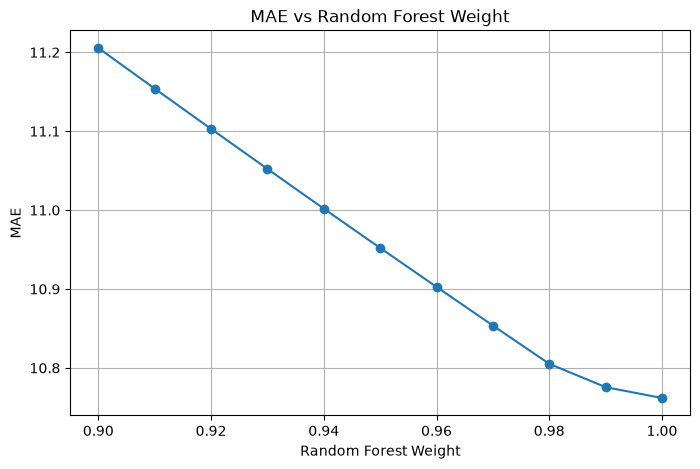

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    fine_results["RF_weight"],
    fine_results["MAE"],
    marker="o"
)
plt.xlabel("Random Forest Weight")
plt.ylabel("MAE")
plt.title("MAE vs Random Forest Weight")
plt.grid(True)
plt.show()

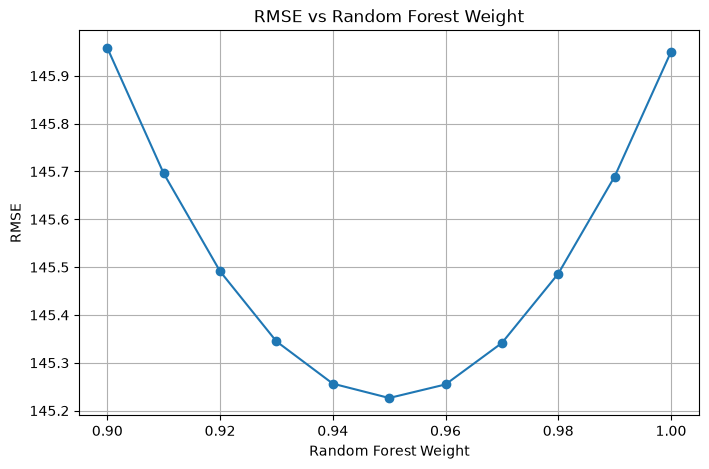

In [76]:
plt.figure(figsize=(8, 5))
plt.plot(
    fine_results["RF_weight"],
    fine_results["RMSE"],
    marker="o"
)
plt.xlabel("Random Forest Weight")
plt.ylabel("RMSE")
plt.title("RMSE vs Random Forest Weight")
plt.grid(True)
plt.show()

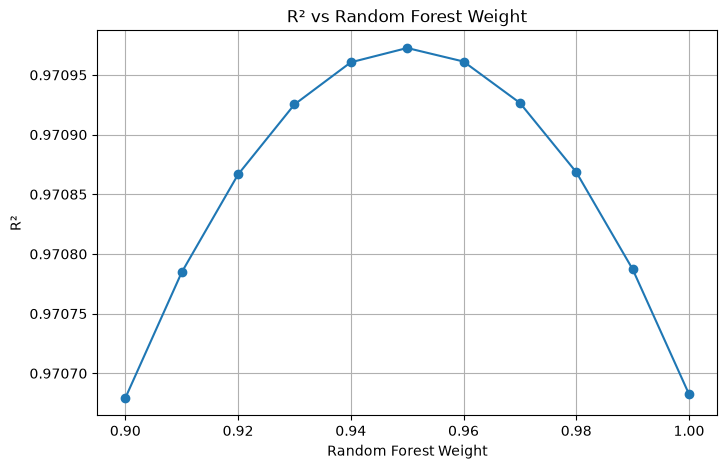

In [77]:
plt.figure(figsize=(8, 5))
plt.plot(
    fine_results["RF_weight"],
    fine_results["R2"],
    marker="o"
)
plt.xlabel("Random Forest Weight")
plt.ylabel("R²")
plt.title("R² vs Random Forest Weight")
plt.grid(True)
plt.show()

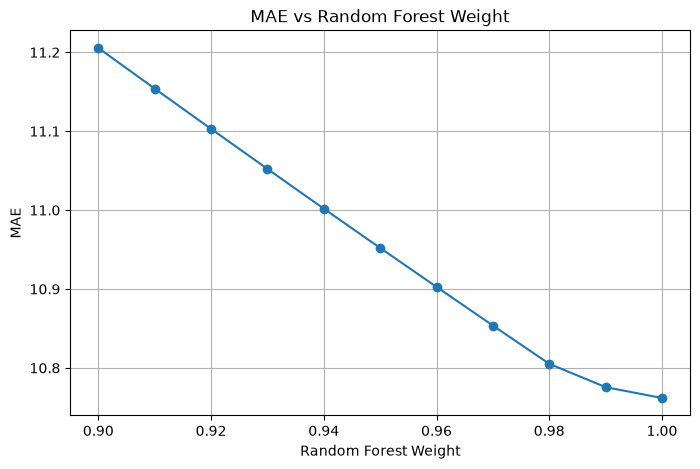

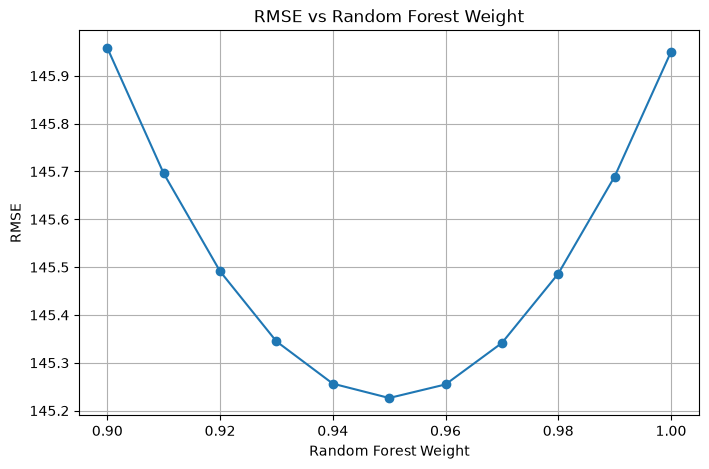

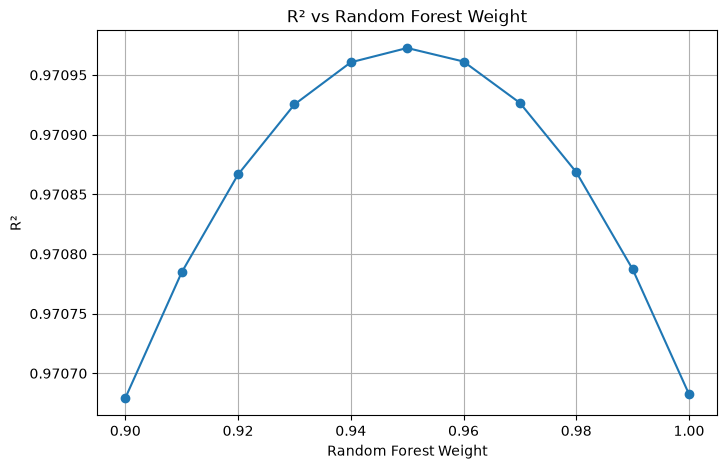

In [78]:
import matplotlib.pyplot as plt

# MAE
plt.figure(figsize=(8, 5))
plt.plot(
    fine_results["RF_weight"],
    fine_results["MAE"],
    marker="o"
)
plt.xlabel("Random Forest Weight")
plt.ylabel("MAE")
plt.title("MAE vs Random Forest Weight")
plt.grid(True)
plt.show()


# RMSE
plt.figure(figsize=(8, 5))
plt.plot(
    fine_results["RF_weight"],
    fine_results["RMSE"],
    marker="o"
)
plt.xlabel("Random Forest Weight")
plt.ylabel("RMSE")
plt.title("RMSE vs Random Forest Weight")
plt.grid(True)
plt.show()


# R²
plt.figure(figsize=(8, 5))
plt.plot(
    fine_results["RF_weight"],
    fine_results["R2"],
    marker="o"
)
plt.xlabel("Random Forest Weight")
plt.ylabel("R²")
plt.title("R² vs Random Forest Weight")
plt.grid(True)
plt.show()

In [79]:
# ============================================================
# CHECK WHETHER A SEPARATE TEST SET EXISTS
# ============================================================

print("=" * 60)
print("CHECKING FOR TRAIN / VALIDATION / TEST DATA")
print("=" * 60)

# Common test-set variable names
possible_test_vars = [
    "X_test",
    "y_test",
    "X_testing",
    "y_testing",
    "test_actual",
    "test_predicted",
    "test_predictions",
    "rf_test",
    "trend_test",
    "rf_test_pred",
    "trend_test_pred"
]

found_test_vars = []

for var in possible_test_vars:
    if var in globals():
        found_test_vars.append(var)

# Display results
if found_test_vars:
    print("\nYES — possible TEST variables were found:\n")

    for var in found_test_vars:
        obj = globals()[var]

        try:
            print(f"{var:20s} -> type: {type(obj).__name__}, "
                  f"shape/length: {getattr(obj, 'shape', len(obj))}")
        except:
            print(f"{var:20s} -> type: {type(obj).__name__}")

else:
    print("\nNO obvious test-set variables were found.")

print("\n" + "-" * 60)

# Check the variables we know already exist
known_vars = [
    "comparison",
    "trend_actual",
    "rf_valid",
    "trend_predicted",
    "fine_results"
]

print("CURRENT MODEL VARIABLES:")
print("-" * 60)

for var in known_vars:
    if var in globals():
        obj = globals()[var]

        try:
            print(f"{var:20s} -> type: {type(obj).__name__}, "
                  f"shape/length: {getattr(obj, 'shape', len(obj))}")
        except:
            print(f"{var:20s} -> type: {type(obj).__name__}")
    else:
        print(f"{var:20s} -> NOT FOUND")

print("\n" + "=" * 60)

# Final answer
if found_test_vars:
    print("ANSWER: A possible separate TEST SET EXISTS.")
    print("Found:", ", ".join(found_test_vars))
    print("\nPaste this output back to me.")
else:
    print("ANSWER: I cannot find a separate TEST SET.")
    print("We need to inspect your train/validation split code.")
    print("\nPaste this output back to me.")
    
print("=" * 60)

CHECKING FOR TRAIN / VALIDATION / TEST DATA

YES — possible TEST variables were found:

X_test               -> type: DataFrame, shape/length: (3938, 8)
y_test               -> type: Series, shape/length: (3938,)

------------------------------------------------------------
CURRENT MODEL VARIABLES:
------------------------------------------------------------
comparison           -> type: DataFrame, shape/length: (4275, 3)
trend_actual         -> type: ndarray, shape/length: (4275,)
rf_valid             -> type: ndarray, shape/length: (4275,)
trend_predicted      -> type: ndarray, shape/length: (4275,)
fine_results         -> type: DataFrame, shape/length: (11, 5)

ANSWER: A possible separate TEST SET EXISTS.
Found: X_test, y_test

Paste this output back to me.


In [80]:
# ============================================================
# CHECK TRAINED MODELS AVAILABLE FOR THE TEST SET
# ============================================================

print("=" * 60)
print("CHECKING TRAINED MODEL VARIABLES")
print("=" * 60)

possible_models = [
    "rf_model",
    "rf",
    "random_forest",
    "rf_model_final",
    "model_rf",
    "trend_model",
    "time_trend_model",
    "trend",
    "model_trend"
]

found_models = []

for var in possible_models:
    if var in globals():
        obj = globals()[var]
        found_models.append(var)

        print(
            f"{var:20s} -> "
            f"type: {type(obj).__name__}"
        )

print("\n" + "-" * 60)

if found_models:
    print("Possible trained model variables found:")
    print(", ".join(found_models))
else:
    print("No obvious trained model variables found.")

print("=" * 60)
print("\nIMPORTANT:")
print("Do NOT retrain anything yet.")
print("Paste this output back to me.")

CHECKING TRAINED MODEL VARIABLES
rf_model             -> type: RandomForestRegressor
trend_model          -> type: LinearRegression

------------------------------------------------------------
Possible trained model variables found:
rf_model, trend_model

IMPORTANT:
Do NOT retrain anything yet.
Paste this output back to me.


In [81]:
# ============================================================
# FINAL TEST-SET EVALUATION
# RF ONLY vs 95% RF + 5% TIME TREND
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. RANDOM FOREST TEST PREDICTIONS
# ------------------------------------------------------------

rf_test_pred = rf_model.predict(X_test)


# ------------------------------------------------------------
# 2. TIME TREND TEST PREDICTIONS
# ------------------------------------------------------------

trend_test_pred = trend_model.predict(X_test)


# ------------------------------------------------------------
# 3. 95% RF + 5% TIME TREND ENSEMBLE
# ------------------------------------------------------------

rf_weight = 0.95
trend_weight = 0.05

ensemble_test_pred = (
    rf_weight * rf_test_pred
    + trend_weight * trend_test_pred
)


# ------------------------------------------------------------
# 4. CALCULATE METRICS
# ------------------------------------------------------------

rf_mae = mean_absolute_error(y_test, rf_test_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_r2 = r2_score(y_test, rf_test_pred)

ensemble_mae = mean_absolute_error(
    y_test,
    ensemble_test_pred
)

ensemble_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ensemble_test_pred
    )
)

ensemble_r2 = r2_score(
    y_test,
    ensemble_test_pred
)


# ------------------------------------------------------------
# 5. CREATE FINAL COMPARISON TABLE
# ------------------------------------------------------------

test_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "95% RF + 5% Time Trend"
    ],
    "MAE": [
        rf_mae,
        ensemble_mae
    ],
    "RMSE": [
        rf_rmse,
        ensemble_rmse
    ],
    "R2": [
        rf_r2,
        ensemble_r2
    ]
})


# ------------------------------------------------------------
# 6. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TEST-SET RESULTS")
print("=" * 70)

print("\nNumber of test samples:", len(y_test))

print("\n")
print(
    test_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------------------
# 7. CALCULATE IMPROVEMENT
# ------------------------------------------------------------

mae_change = (
    (rf_mae - ensemble_mae)
    / rf_mae
) * 100

rmse_change = (
    (rf_rmse - ensemble_rmse)
    / rf_rmse
) * 100

r2_change = (
    ensemble_r2 - rf_r2
)

print("\n" + "-" * 70)
print("ENSEMBLE IMPROVEMENT RELATIVE TO RANDOM FOREST")
print("-" * 70)

print(f"\nMAE improvement : {mae_change:.4f}%")
print(f"RMSE improvement: {rmse_change:.4f}%")
print(f"R² improvement  : {r2_change:.6f}")

print("\n" + "=" * 70)

c:\Users\zulki\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'Peas & beans (Pulses)'

In [82]:
# ============================================================
# DIAGNOSE X_TEST AND THE DATA USED TO TRAIN RF_MODEL
# ============================================================

print("=" * 70)
print("X_TEST INFORMATION")
print("=" * 70)

print("\nX_test shape:")
print(X_test.shape)

print("\nX_test columns:")
print(list(X_test.columns))

print("\nX_test data types:")
print(X_test.dtypes)

print("\nFirst 5 rows of X_test:")
print(X_test.head())


print("\n" + "=" * 70)
print("RANDOM FOREST MODEL INFORMATION")
print("=" * 70)

print("\nNumber of features expected by RF:")
print(rf_model.n_features_in_)

if hasattr(rf_model, "feature_names_in_"):
    print("\nFeatures used when training RF:")
    print(list(rf_model.feature_names_in_))

print("\n" + "=" * 70)
print("CHECKING FOR ENCODERS / SCALERS")
print("=" * 70)

possible_preprocessors = [
    "encoder",
    "label_encoder",
    "onehot_encoder",
    "ordinal_encoder",
    "scaler",
    "standard_scaler",
    "minmax_scaler",
    "preprocessor",
    "transformer",
    "ct",
    "column_transformer"
]

found = []

for var in possible_preprocessors:
    if var in globals():
        obj = globals()[var]
        found.append(var)
        print(
            f"{var:20s} -> {type(obj).__name__}"
        )

if not found:
    print("\nNo common encoder/scaler variables found.")

print("\n" + "=" * 70)
print("CHECKING COMMON TRAINING DATA VARIABLES")
print("=" * 70)

possible_training_vars = [
    "X_train",
    "X_valid",
    "X_val",
    "y_train",
    "y_valid",
    "X",
    "X_encoded",
    "X_train_encoded",
    "X_valid_encoded",
    "X_val_encoded"
]

for var in possible_training_vars:
    if var in globals():
        obj = globals()[var]

        try:
            print(
                f"{var:20s} -> "
                f"type={type(obj).__name__}, "
                f"shape={obj.shape}"
            )
        except:
            print(
                f"{var:20s} -> "
                f"type={type(obj).__name__}"
            )

print("\n" + "=" * 70)
print("END OF DIAGNOSTIC")
print("=" * 70)

X_TEST INFORMATION

X_test shape:
(3938, 8)

X_test columns:
['crop', 'year', 'season', 'state', 'area', 'annual_rainfall', 'fertilizer', 'pesticide']

X_test data types:
crop                   str
year                 int64
season                 str
state                  str
area               float64
annual_rainfall    float64
fertilizer         float64
pesticide          float64
dtype: object

First 5 rows of X_test:
                        crop  year  season              state      area  \
18238  Peas & beans (Pulses)  2016  Kharif  Jammu and Kashmir    210.00   
6918                   Maize  1999    Rabi             Odisha   8270.00   
4894                  Potato  2016  Winter          Meghalaya   6341.00   
10960                   Ragi  2008  Autumn          Jharkhand  29768.73   
15615            Castor seed  2017  Kharif     Madhya Pradesh   8950.00   

       annual_rainfall   fertilizer  pesticide  
18238            902.8    32182.500    73.5000  
6918            1484.3   

In [83]:
print("=" * 60)
print("RF MODEL EXPECTATIONS")
print("=" * 60)

print("Expected number of features:", rf_model.n_features_in_)

if hasattr(rf_model, "feature_names_in_"):
    print("Features used by RF:")
    print(list(rf_model.feature_names_in_))
else:
    print("RF does not contain feature_names_in_.")


print("\n" + "=" * 60)
print("ALL DATAFRAME VARIABLES")
print("=" * 60)

for name, obj in globals().items():
    try:
        if isinstance(obj, pd.DataFrame):
            print(
                f"{name:30s} shape={obj.shape}"
            )
            print(
                "   columns:",
                list(obj.columns)
            )
    except RuntimeError:
        pass


print("\n" + "=" * 60)
print("ALL POSSIBLE ENCODER / PREPROCESSOR VARIABLES")
print("=" * 60)

for name, obj in globals().items():
    try:
        class_name = type(obj).__name__.lower()

        if any(word in class_name for word in [
            "encoder",
            "transformer",
            "scaler",
            "columntransformer",
            "pipeline"
        ]):
            print(
                f"{name:30s} -> {type(obj).__name__}"
            )
    except RuntimeError:
        pass

print("=" * 60)

RF MODEL EXPECTATIONS
Expected number of features: 96
RF does not contain feature_names_in_.

ALL DATAFRAME VARIABLES


RuntimeError: dictionary changed size during iteration

In [84]:
# ============================================================
# FIND HOW THE 8 RAW FEATURES BECAME 96 FEATURES
# ============================================================

print("=" * 70)
print("RF MODEL")
print("=" * 70)

print("RF expects:", rf_model.n_features_in_, "features")


# ------------------------------------------------------------
# SAFELY COPY GLOBAL VARIABLES BEFORE ITERATING
# ------------------------------------------------------------

all_variables = list(globals().items())


# ------------------------------------------------------------
# FIND DATAFRAMES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATAFRAMES")
print("=" * 70)

for name, obj in all_variables:

    if isinstance(obj, pd.DataFrame):

        print(
            f"\n{name}: shape = {obj.shape}"
        )

        print(
            "Columns:",
            list(obj.columns)[:15]
        )


# ------------------------------------------------------------
# FIND ENCODERS / TRANSFORMERS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ENCODERS / TRANSFORMERS / SCALERS")
print("=" * 70)

found = False

for name, obj in all_variables:

    try:

        class_name = type(obj).__name__.lower()

        if any(word in class_name for word in [
            "encoder",
            "transformer",
            "scaler",
            "columntransformer",
            "pipeline"
        ]):

            print(
                f"{name:30s} -> {type(obj).__name__}"
            )

            found = True

    except:
        pass


if not found:
    print("No encoder/transformer/scaler found.")


# ------------------------------------------------------------
# FIND OBJECTS WITH "ENCODE" IN THE VARIABLE NAME
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VARIABLES WITH 'ENCOD' IN NAME")
print("=" * 70)

found = False

for name, obj in all_variables:

    if "encod" in name.lower():

        print(
            f"{name:30s} -> {type(obj).__name__}"
        )

        found = True

if not found:
    print("None found.")


# ------------------------------------------------------------
# FIND OBJECTS WITH "PREPROCESS" IN NAME
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VARIABLES WITH 'PREPROCESS' IN NAME")
print("=" * 70)

found = False

for name, obj in all_variables:

    if "preprocess" in name.lower():

        print(
            f"{name:30s} -> {type(obj).__name__}"
        )

        found = True

if not found:
    print("None found.")


print("\n" + "=" * 70)
print("END")
print("=" * 70)

RF MODEL
RF expects: 96 features

DATAFRAMES

__: shape = (5, 8)
Columns: ['crop', 'year', 'season', 'state', 'area', 'annual_rainfall', 'fertilizer', 'pesticide']

df: shape = (19689, 9)
Columns: ['crop', 'year', 'season', 'state', 'area', 'annual_rainfall', 'fertilizer', 'pesticide', 'yield']

_3: shape = (5, 9)
Columns: ['crop', 'year', 'season', 'state', 'area', 'annual_rainfall', 'fertilizer', 'pesticide', 'yield']

_8: shape = (5, 9)
Columns: ['crop', 'year', 'season', 'state', 'area', 'annual_rainfall', 'fertilizer', 'pesticide', 'yield']

X: shape = (19689, 8)
Columns: ['crop', 'year', 'season', 'state', 'area', 'annual_rainfall', 'fertilizer', 'pesticide']

_12: shape = (5, 8)
Columns: ['crop', 'year', 'season', 'state', 'area', 'annual_rainfall', 'fertilizer', 'pesticide']

X_train: shape = (15751, 8)
Columns: ['crop', 'year', 'season', 'state', 'area', 'annual_rainfall', 'fertilizer', 'pesticide']

X_test: shape = (3938, 8)
Columns: ['crop', 'year', 'season', 'state', 'area'

In [85]:
# ============================================================
# FIND THE 96-FEATURE TRAINING DATA / ENCODER
# ============================================================

print("=" * 70)
print("LOOKING FOR 96-FEATURE DATA")
print("=" * 70)

all_variables = list(globals().items())

for name, obj in all_variables:

    try:

        # Check DataFrames
        if isinstance(obj, pd.DataFrame):

            if obj.shape[1] == 96:

                print(
                    f"\nFOUND DATAFRAME: {name}"
                )
                print(
                    f"Shape: {obj.shape}"
                )
                print(
                    "First 20 columns:"
                )
                print(
                    list(obj.columns[:20])
                )

        # Check NumPy arrays
        elif isinstance(obj, np.ndarray):

            if obj.ndim == 2 and obj.shape[1] == 96:

                print(
                    f"\nFOUND ARRAY: {name}"
                )
                print(
                    f"Shape: {obj.shape}"
                )

    except:
        pass


# ============================================================
# FIND ENCODERS
# ============================================================

print("\n" + "=" * 70)
print("ENCODERS / PREPROCESSORS")
print("=" * 70)

for name, obj in all_variables:

    try:

        class_name = type(obj).__name__

        if any(word in class_name.lower() for word in [
            "encoder",
            "columntransformer",
            "pipeline",
            "transformer",
            "scaler"
        ]):

            print(
                f"{name:30s} -> {class_name}"
            )

    except:
        pass


# ============================================================
# FIND VARIABLES WITH X_TRAIN / X_VALID
# ============================================================

print("\n" + "=" * 70)
print("TRAIN / VALIDATION VARIABLES")
print("=" * 70)

for name, obj in all_variables:

    try:

        name_lower = name.lower()

        if (
            "train" in name_lower
            or "valid" in name_lower
            or "val" in name_lower
        ):

            if isinstance(obj, (pd.DataFrame, np.ndarray)):

                print(
                    f"{name:30s} -> shape={obj.shape}"
                )

    except:
        pass


print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

LOOKING FOR 96-FEATURE DATA

ENCODERS / PREPROCESSORS
preprocessor                   -> ColumnTransformer
final_model                    -> Pipeline
time_preprocessor              -> ColumnTransformer
time_rf_pipeline               -> Pipeline

TRAIN / VALIDATION VARIABLES
X_train                        -> shape=(15751, 8)
X_time_train                   -> shape=(15404, 8)
trend_train_data               -> shape=(15404, 3)
trend_train_yearly             -> shape=(1011, 3)
valid_mask                     -> shape=(4285,)
rf_valid                       -> shape=(4275,)

DONE


In [86]:
# Check whether the complete Random Forest pipeline
# can directly process the raw X_test data

print("Final model type:", type(final_model).__name__)

print("X_test shape:", X_test.shape)

try:
    test_prediction_check = final_model.predict(X_test)

    print("\nSUCCESS!")
    print("Prediction shape:", test_prediction_check.shape)
    print("First 10 predictions:")
    print(test_prediction_check[:10])

except Exception as e:
    print("\nERROR:")
    print(type(e).__name__)
    print(e)

Final model type: Pipeline
X_test shape: (3938, 8)

SUCCESS!
Prediction shape: (3938,)
First 10 predictions:
[ 3.76473333  1.40497724  6.5411569   0.80443901  0.52713571  0.44314602
  0.71786112  1.91723661 77.4696217   1.7941    ]


In [87]:
# ============================================================
# CHECK TIME TREND PIPELINE ON TEST DATA
# ============================================================

print("Time model type:", type(time_rf_pipeline).__name__)
print("X_test shape:", X_test.shape)

try:
    trend_test_check = time_rf_pipeline.predict(X_test)

    print("\nSUCCESS!")
    print("Trend prediction shape:", trend_test_check.shape)

    print("\nFirst 10 trend predictions:")
    print(trend_test_check[:10])

except Exception as e:
    print("\nERROR:")
    print(type(e).__name__)
    print(e)

Time model type: Pipeline
X_test shape: (3938, 8)

SUCCESS!
Trend prediction shape: (3938,)

First 10 trend predictions:
[ 3.12610405  1.40635906  6.90553239  0.78791862  0.43825019  0.43198925
  0.71790749  2.28330312 77.15905167  1.7937    ]


In [88]:
# ============================================================
# FINAL UNSEEN TEST-SET EVALUATION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. Generate test predictions
# ------------------------------------------------------------

rf_test_pred = final_model.predict(X_test)

trend_test_pred = time_rf_pipeline.predict(X_test)


# ------------------------------------------------------------
# 2. Create 95% RF + 5% Trend ensemble
# ------------------------------------------------------------

rf_weight = 0.95
trend_weight = 0.05

ensemble_test_pred = (
    rf_weight * rf_test_pred
    + trend_weight * trend_test_pred
)


# ------------------------------------------------------------
# 3. Calculate metrics
# ------------------------------------------------------------

rf_mae = mean_absolute_error(y_test, rf_test_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_r2 = r2_score(y_test, rf_test_pred)

ensemble_mae = mean_absolute_error(
    y_test,
    ensemble_test_pred
)

ensemble_rmse = np.sqrt(
    mean_squared_error(y_test, ensemble_test_pred)
)

ensemble_r2 = r2_score(
    y_test,
    ensemble_test_pred
)


# ------------------------------------------------------------
# 4. Create comparison table
# ------------------------------------------------------------

final_test_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "95% RF + 5% Time Trend"
    ],
    "MAE": [
        rf_mae,
        ensemble_mae
    ],
    "RMSE": [
        rf_rmse,
        ensemble_rmse
    ],
    "R2": [
        rf_r2,
        ensemble_r2
    ]
})


# ------------------------------------------------------------
# 5. Print results
# ------------------------------------------------------------

print("=" * 75)
print("FINAL UNSEEN TEST-SET RESULTS")
print("=" * 75)

print("\nTest samples:", len(y_test))

print("\n")
print(
    final_test_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ------------------------------------------------------------
# 6. Calculate changes from RF → Ensemble
# ------------------------------------------------------------

mae_change = ((ensemble_mae - rf_mae) / rf_mae) * 100
rmse_change = ((ensemble_rmse - rf_rmse) / rf_rmse) * 100
r2_change = ensemble_r2 - rf_r2

print("\n" + "-" * 75)
print("CHANGE: 95/5 ENSEMBLE RELATIVE TO RANDOM FOREST")
print("-" * 75)

print(f"\nMAE change : {mae_change:+.4f}%")
print(f"RMSE change: {rmse_change:+.4f}%")
print(f"R² change  : {r2_change:+.6f}")

print("\n" + "=" * 75)

FINAL UNSEEN TEST-SET RESULTS

Test samples: 3938


                 Model      MAE      RMSE       R2
         Random Forest 2.763570 44.942275 0.997479
95% RF + 5% Time Trend 2.801564 46.332409 0.997321

---------------------------------------------------------------------------
CHANGE: 95/5 ENSEMBLE RELATIVE TO RANDOM FOREST
---------------------------------------------------------------------------

MAE change : +1.3748%
RMSE change: +3.0932%
R² change  : -0.000158



In [89]:
# ============================================================
# VALIDATION vs TEST DATASET DIAGNOSTIC
# ============================================================

import numpy as np
import pandas as pd

print("=" * 75)
print("VALIDATION vs TEST COMPARISON")
print("=" * 75)


# ------------------------------------------------------------
# 1. BASIC SIZE
# ------------------------------------------------------------

print("\n1. DATASET SIZE")
print("-" * 50)

print("Validation samples :", len(trend_actual))
print("Test samples       :", len(y_test))


# ------------------------------------------------------------
# 2. ACTUAL YIELD STATISTICS
# ------------------------------------------------------------

print("\n2. ACTUAL YIELD STATISTICS")
print("-" * 50)

comparison_stats = pd.DataFrame({
    "Validation": pd.Series(trend_actual).describe(),
    "Test": pd.Series(y_test).describe()
})

print(comparison_stats)


# ------------------------------------------------------------
# 3. PREDICTION ERROR STATISTICS
# ------------------------------------------------------------

print("\n3. RANDOM FOREST ERROR STATISTICS")
print("-" * 50)

# Validation RF error
validation_rf_error = np.asarray(trend_actual) - np.asarray(rf_valid)

# Test RF error
test_rf_error = np.asarray(y_test) - np.asarray(rf_test_pred)

error_stats = pd.DataFrame({
    "Validation_RF_Error": pd.Series(validation_rf_error).describe(),
    "Test_RF_Error": pd.Series(test_rf_error).describe()
})

print(error_stats)


# ------------------------------------------------------------
# 4. ABSOLUTE ERROR
# ------------------------------------------------------------

validation_abs_error = np.abs(validation_rf_error)
test_abs_error = np.abs(test_rf_error)

print("\n4. ABSOLUTE ERROR")
print("-" * 50)

print(
    f"Validation mean absolute error: "
    f"{validation_abs_error.mean():.6f}"
)

print(
    f"Test mean absolute error      : "
    f"{test_abs_error.mean():.6f}"
)

print(
    f"Validation median absolute error: "
    f"{np.median(validation_abs_error):.6f}"
)

print(
    f"Test median absolute error      : "
    f"{np.median(test_abs_error):.6f}"
)

print(
    f"Validation maximum error: "
    f"{validation_abs_error.max():.6f}"
)

print(
    f"Test maximum error      : "
    f"{test_abs_error.max():.6f}"
)


# ------------------------------------------------------------
# 5. EXTREME YIELD VALUES
# ------------------------------------------------------------

print("\n5. EXTREME ACTUAL YIELDS")
print("-" * 50)

print(
    "Validation minimum:",
    np.min(trend_actual)
)

print(
    "Validation maximum:",
    np.max(trend_actual)
)

print(
    "Test minimum:",
    np.min(y_test)
)

print(
    "Test maximum:",
    np.max(y_test)
)


# ------------------------------------------------------------
# 6. HIGH-YIELD OBSERVATIONS
# ------------------------------------------------------------

print("\n6. HIGH-YIELD OBSERVATIONS")
print("-" * 50)

validation_high = np.sum(np.asarray(trend_actual) > 100)
test_high = np.sum(np.asarray(y_test) > 100)

print(
    "Validation yield > 100:",
    validation_high
)

print(
    "Test yield > 100:",
    test_high
)

print(
    "Validation yield > 500:",
    np.sum(np.asarray(trend_actual) > 500)
)

print(
    "Test yield > 500:",
    np.sum(np.asarray(y_test) > 500)
)


# ------------------------------------------------------------
# 7. ERROR PERCENTILES
# ------------------------------------------------------------

print("\n7. ABSOLUTE ERROR PERCENTILES")
print("-" * 50)

percentiles = [50, 75, 90, 95, 99]

for p in percentiles:

    val_p = np.percentile(validation_abs_error, p)
    test_p = np.percentile(test_abs_error, p)

    print(
        f"{p:>2}th percentile | "
        f"Validation = {val_p:.6f} | "
        f"Test = {test_p:.6f}"
    )


print("\n" + "=" * 75)
print("DIAGNOSTIC COMPLETE")
print("=" * 75)

VALIDATION vs TEST COMPARISON

1. DATASET SIZE
--------------------------------------------------
Validation samples : 4275
Test samples       : 3938

2. ACTUAL YIELD STATISTICS
--------------------------------------------------
         Validation          Test
count   4275.000000   3938.000000
mean      75.130417     79.216731
std      852.495732    895.233701
min        0.000000      0.000000
25%        0.708246      0.600000
50%        1.163077      1.026458
75%        2.720000      2.315521
max    16935.058460  16935.058460

3. RANDOM FOREST ERROR STATISTICS
--------------------------------------------------
       Validation_RF_Error  Test_RF_Error
count          4275.000000    3938.000000
mean             -0.491049       0.652629
std             145.966324      44.943243
min           -3572.225233   -1425.380631
25%              -0.144596      -0.049750
50%               0.031907      -0.004160
75%               0.268120       0.033288
max            4557.855853    1665.675626



In [91]:
print("=" * 75)
print("CRITICAL ERROR DIAGNOSTIC")
print("=" * 75)

val_actual = np.asarray(trend_actual)
val_pred = np.asarray(rf_valid)

test_actual = np.asarray(y_test)
test_pred = np.asarray(rf_test_pred)

val_error = val_actual - val_pred
test_error = test_actual - test_pred

val_abs = np.abs(val_error)
test_abs = np.abs(test_error)

# ------------------------------------------------------------
# 1. MAE / RMSE / R2
# ------------------------------------------------------------

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("\n1. METRICS")
print("-" * 50)

print("Validation:")
print("  MAE :", mean_absolute_error(val_actual, val_pred))
print("  RMSE:", np.sqrt(mean_squared_error(val_actual, val_pred)))
print("  R2  :", r2_score(val_actual, val_pred))

print("\nTest:")
print("  MAE :", mean_absolute_error(test_actual, test_pred))
print("  RMSE:", np.sqrt(mean_squared_error(test_actual, test_pred)))
print("  R2  :", r2_score(test_actual, test_pred))


# ------------------------------------------------------------
# 2. WORST VALIDATION ERRORS
# ------------------------------------------------------------

print("\n2. TOP 20 VALIDATION ERRORS")
print("-" * 50)

val_idx = np.argsort(val_abs)[-20:][::-1]

for i in val_idx:
    print(
        f"Actual={val_actual[i]:12.3f} | "
        f"Predicted={val_pred[i]:12.3f} | "
        f"Error={val_error[i]:12.3f} | "
        f"AbsError={val_abs[i]:12.3f}"
    )


# ------------------------------------------------------------
# 3. WORST TEST ERRORS
# ------------------------------------------------------------

print("\n3. TOP 20 TEST ERRORS")
print("-" * 50)

test_idx = np.argsort(test_abs)[-20:][::-1]

for i in test_idx:
    print(
        f"Actual={test_actual[i]:12.3f} | "
        f"Predicted={test_pred[i]:12.3f} | "
        f"Error={test_error[i]:12.3f} | "
        f"AbsError={test_abs[i]:12.3f}"
    )


# ------------------------------------------------------------
# 4. ERROR BY YIELD RANGE
# ------------------------------------------------------------

print("\n4. ERROR BY YIELD RANGE")
print("-" * 50)

bins = [0, 1, 5, 10, 50, 100, 500, 1000, np.inf]
labels = [
    "0-1",
    "1-5",
    "5-10",
    "10-50",
    "50-100",
    "100-500",
    "500-1000",
    "1000+"
]

for name, actual, pred in [
    ("Validation", val_actual, val_pred),
    ("Test", test_actual, test_pred)
]:

    print(f"\n{name}")

    groups = pd.cut(
        actual,
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    for label in labels:

        mask = groups == label

        if mask.sum() == 0:
            continue

        mae = mean_absolute_error(
            actual[mask],
            pred[mask]
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual[mask],
                pred[mask]
            )
        )

        print(
            f"{label:>10} | "
            f"N={mask.sum():4d} | "
            f"MAE={mae:12.3f} | "
            f"RMSE={rmse:12.3f}"
        )


# ------------------------------------------------------------
# 5. EXTREME VALUES
# ------------------------------------------------------------

print("\n5. EXTREME OBSERVATIONS")
print("-" * 50)

for threshold in [10, 50, 100, 500, 1000, 5000, 10000]:

    v = np.sum(val_actual > threshold)
    t = np.sum(test_actual > threshold)

    print(
        f">{threshold:5} | "
        f"Validation={v:4d} | "
        f"Test={t:4d}"
    )


print("\n" + "=" * 75)
print("CRITICAL DIAGNOSTIC COMPLETE")
print("=" * 75)

CRITICAL ERROR DIAGNOSTIC

1. METRICS
--------------------------------------------------
Validation:
  MAE : 10.761864357174536
  RMSE: 145.95007651782703
  R2  : 0.9706825746329905

Test:
  MAE : 2.7635698034588527
  RMSE: 44.94227469035734
  R2  : 0.9974791468288027

2. TOP 20 VALIDATION ERRORS
--------------------------------------------------
Actual=   16935.058 | Predicted=   12377.203 | Error=    4557.856 | AbsError=    4557.856
Actual=    8363.155 | Predicted=   11935.380 | Error=   -3572.225 | AbsError=    3572.225
Actual=   15636.632 | Predicted=   12142.776 | Error=    3493.857 | AbsError=    3493.857
Actual=    8795.261 | Predicted=   11429.492 | Error=   -2634.232 | AbsError=    2634.232
Actual=    9387.335 | Predicted=   11972.046 | Error=   -2584.711 | AbsError=    2584.711
Actual=    9474.625 | Predicted=   11664.129 | Error=   -2189.504 | AbsError=    2189.504
Actual=    9156.942 | Predicted=    6975.470 | Error=    2181.472 | AbsError=    2181.472
Actual=    8735.671 |

In [92]:
# ============================================================
# STEP 3 — TRAIN / VALIDATION / TEST SPLIT STRUCTURE
# ============================================================

print("=" * 75)
print("CHECKING TRAIN / VALIDATION / TEST STRUCTURE")
print("=" * 75)

print("\nAvailable variables:")
for name in [
    "X_train", "X_valid", "X_test",
    "y_train", "y_valid", "y_test",
    "trend_actual", "rf_valid", "rf_test_pred"
]:
    print(f"{name:20s} :", "YES" if name in globals() else "NO")


# ------------------------------------------------------------
# 1. SHAPES
# ------------------------------------------------------------

print("\n1. SHAPES")
print("-" * 50)

for name in [
    "X_train", "X_valid", "X_test",
    "y_train", "y_valid", "y_test"
]:

    if name in globals():
        obj = globals()[name]
        print(f"{name:20s}: {getattr(obj, 'shape', len(obj))}")


# ------------------------------------------------------------
# 2. CHECK INDEX OVERLAP
# ------------------------------------------------------------

print("\n2. INDEX OVERLAP")
print("-" * 50)

for a_name, b_name in [
    ("X_train", "X_valid"),
    ("X_train", "X_test"),
    ("X_valid", "X_test")
]:

    if a_name in globals() and b_name in globals():

        a = globals()[a_name]
        b = globals()[b_name]

        try:
            overlap = len(set(a.index).intersection(set(b.index)))
            print(
                f"{a_name} vs {b_name}: "
                f"{overlap} overlapping indices"
            )
        except Exception as e:
            print(
                f"{a_name} vs {b_name}: "
                f"could not check index ({e})"
            )


# ------------------------------------------------------------
# 3. CHECK DUPLICATE FEATURE ROWS
# ------------------------------------------------------------

print("\n3. DUPLICATE FEATURE ROWS")
print("-" * 50)

try:

    train_features = pd.DataFrame(X_train).reset_index(drop=True)
    valid_features = pd.DataFrame(X_valid).reset_index(drop=True)
    test_features = pd.DataFrame(X_test).reset_index(drop=True)

    train_hash = pd.util.hash_pandas_object(
        train_features,
        index=False
    )

    valid_hash = pd.util.hash_pandas_object(
        valid_features,
        index=False
    )

    test_hash = pd.util.hash_pandas_object(
        test_features,
        index=False
    )

    print(
        "Train duplicate rows:",
        train_features.duplicated().sum()
    )

    print(
        "Validation duplicate rows:",
        valid_features.duplicated().sum()
    )

    print(
        "Test duplicate rows:",
        test_features.duplicated().sum()
    )

    print(
        "Train ↔ Validation identical rows:",
        len(set(train_hash).intersection(set(valid_hash)))
    )

    print(
        "Train ↔ Test identical rows:",
        len(set(train_hash).intersection(set(test_hash)))
    )

    print(
        "Validation ↔ Test identical rows:",
        len(set(valid_hash).intersection(set(test_hash)))
    )

except Exception as e:

    print("Duplicate-row check failed:", e)


# ------------------------------------------------------------
# 4. TARGET DUPLICATES / EXTREMES
# ------------------------------------------------------------

print("\n4. EXTREME TARGET COUNTS")
print("-" * 50)

for name in ["y_train", "y_valid", "y_test"]:

    if name in globals():

        arr = np.asarray(globals()[name])

        print(
            f"{name:10s} | "
            f">100={np.sum(arr > 100):4d} | "
            f">500={np.sum(arr > 500):4d} | "
            f">1000={np.sum(arr > 1000):4d} | "
            f">5000={np.sum(arr > 5000):4d} | "
            f">10000={np.sum(arr > 10000):4d}"
        )


print("\n" + "=" * 75)
print("STRUCTURE CHECK COMPLETE")
print("=" * 75)

CHECKING TRAIN / VALIDATION / TEST STRUCTURE

Available variables:
X_train              : YES
X_valid              : NO
X_test               : YES
y_train              : YES
y_valid              : NO
y_test               : YES
trend_actual         : YES
rf_valid             : YES
rf_test_pred         : YES

1. SHAPES
--------------------------------------------------
X_train             : (15751, 8)
X_test              : (3938, 8)
y_train             : (15751,)
y_test              : (3938,)

2. INDEX OVERLAP
--------------------------------------------------
X_train vs X_test: 0 overlapping indices

3. DUPLICATE FEATURE ROWS
--------------------------------------------------
Duplicate-row check failed: name 'X_valid' is not defined

4. EXTREME TARGET COUNTS
--------------------------------------------------
y_train    | >100= 167 | >500= 133 | >1000= 132 | >5000= 116 | >10000=  50
y_test     | >100=  37 | >500=  32 | >1000=  32 | >5000=  27 | >10000=  14

STRUCTURE CHECK COMPLETE


In [93]:
# ============================================================
# STEP 4 — IDENTIFY VALIDATION DATA
# ============================================================

print("=" * 75)
print("VALIDATION VARIABLE INVESTIGATION")
print("=" * 75)

print("\nVariable types and sizes")
print("-" * 50)

for name in [
    "trend_actual",
    "rf_valid",
    "rf_test_pred",
    "y_train",
    "y_test",
    "X_train",
    "X_test"
]:

    if name in globals():

        obj = globals()[name]

        print(
            f"{name:15s} | "
            f"type={type(obj).__name__:15s} | "
            f"shape={getattr(obj, 'shape', 'N/A')} | "
            f"length={len(obj)}"
        )


# ------------------------------------------------------------
# 1. CHECK WHETHER VALIDATION IS A SUBSET OF ORIGINAL DATA
# ------------------------------------------------------------

print("\n1. VALIDATION INDEX INFORMATION")
print("-" * 50)

if hasattr(trend_actual, "index"):

    print("trend_actual index type:", type(trend_actual.index).__name__)

    print("First 10 indices:")
    print(trend_actual.index[:10])

    print("\nLast 10 indices:")
    print(trend_actual.index[-10:])

else:

    print("trend_actual has no pandas index")


if hasattr(rf_valid, "index"):

    print("\nrf_valid index type:", type(rf_valid.index).__name__)

    print("First 10 indices:")
    print(rf_valid.index[:10])

else:

    print("\nrf_valid has no pandas index")


# ------------------------------------------------------------
# 2. CHECK ORIGINAL DATAFRAME VARIABLES
# ------------------------------------------------------------

print("\n2. POSSIBLE ORIGINAL DATASETS")
print("-" * 50)

for name, obj in list(globals().items()):

    if isinstance(obj, pd.DataFrame):

        print(
            f"{name:30s} "
            f"shape={obj.shape}"
        )


# ------------------------------------------------------------
# 3. POSSIBLE SERIES
# ------------------------------------------------------------

print("\n3. POSSIBLE TARGET SERIES")
print("-" * 50)

for name, obj in list(globals().items()):

    if isinstance(obj, pd.Series):

        if len(obj) > 100:

            print(
                f"{name:30s} "
                f"length={len(obj)}"
            )


print("\n" + "=" * 75)
print("VALIDATION INVESTIGATION COMPLETE")
print("=" * 75)

VALIDATION VARIABLE INVESTIGATION

Variable types and sizes
--------------------------------------------------
trend_actual    | type=ndarray         | shape=(4275,) | length=4275
rf_valid        | type=ndarray         | shape=(4275,) | length=4275
rf_test_pred    | type=ndarray         | shape=(3938,) | length=3938
y_train         | type=Series          | shape=(15751,) | length=15751
y_test          | type=Series          | shape=(3938,) | length=3938
X_train         | type=DataFrame       | shape=(15751, 8) | length=15751
X_test          | type=DataFrame       | shape=(3938, 8) | length=3938

1. VALIDATION INDEX INFORMATION
--------------------------------------------------
trend_actual has no pandas index

rf_valid has no pandas index

2. POSSIBLE ORIGINAL DATASETS
--------------------------------------------------
__                             shape=(5, 8)
df                             shape=(19689, 9)
_3                             shape=(5, 9)
_8                             sh

In [94]:
print("=" * 75)
print("FINAL FEATURE / TARGET CHECK")
print("=" * 75)

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

print("\nTarget candidate:")
print("y_train name:", getattr(y_train, "name", None))
print("y_test name :", getattr(y_test, "name", None))

print("\n" + "=" * 75)

FINAL FEATURE / TARGET CHECK

Dataset shape:
(19689, 9)

Columns:
0: crop
1: year
2: season
3: state
4: area
5: annual_rainfall
6: fertilizer
7: pesticide
8: yield

Data types:
crop                   str
year                 int64
season                 str
state                  str
area               float64
annual_rainfall    float64
fertilizer         float64
pesticide          float64
yield              float64
dtype: object

First 5 rows:
           crop  year      season  state     area  annual_rainfall  \
0      Arecanut  1997  Whole Year  Assam  73814.0           2051.4   
1     Arhar/Tur  1997      Kharif  Assam   6637.0           2051.4   
2   Castor seed  1997      Kharif  Assam    796.0           2051.4   
3       Coconut  1997  Whole Year  Assam  19656.0           2051.4   
4  Cotton(lint)  1997      Kharif  Assam   1739.0           2051.4   

   fertilizer  pesticide        yield  
0  7024878.38   22882.34     0.796087  
1   631643.29    2057.47     0.710435  
2    75755

In [95]:
print("=" * 60)
print("YEAR DISTRIBUTION")
print("=" * 60)

print(df["year"].value_counts().sort_index())

print("\nMinimum year:", df["year"].min())
print("Maximum year:", df["year"].max())
print("Number of years:", df["year"].nunique())

YEAR DISTRIBUTION
year
1997     410
1998     646
1999     650
2000     772
2001     750
2002     815
2003     801
2004     787
2005     811
2006     823
2007     828
2008     847
2009     865
2010     859
2011     907
2012     894
2013     976
2014     965
2015     998
2016    1036
2017    1070
2018    1063
2019    1079
2020      37
Name: count, dtype: int64

Minimum year: 1997
Maximum year: 2020
Number of years: 24


In [96]:
# ============================================================
# TEMPORAL ROBUSTNESS TEST
# Train: 1997-2018
# Test : 2019-2020
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 75)
print("TEMPORAL ROBUSTNESS TEST")
print("=" * 75)


# ------------------------------------------------------------
# 1. DEFINE FEATURES / TARGET
# ------------------------------------------------------------

features = [
    "crop",
    "year",
    "season",
    "state",
    "area",
    "annual_rainfall",
    "fertilizer",
    "pesticide"
]

target = "yield"


# ------------------------------------------------------------
# 2. TEMPORAL SPLIT
# ------------------------------------------------------------

train_temporal = df[df["year"] <= 2018].copy()
test_temporal  = df[df["year"] >= 2019].copy()

X_temporal_train = train_temporal[features]
y_temporal_train = train_temporal[target]

X_temporal_test = test_temporal[features]
y_temporal_test = test_temporal[target]


print("\n1. TEMPORAL SPLIT")
print("-" * 50)

print("Training years:",
      train_temporal["year"].min(),
      "to",
      train_temporal["year"].max())

print("Test years:",
      test_temporal["year"].min(),
      "to",
      test_temporal["year"].max())

print("\nTraining samples:", len(train_temporal))
print("Test samples    :", len(test_temporal))


# ------------------------------------------------------------
# 3. PREPROCESSING
# ------------------------------------------------------------

categorical_features = [
    "crop",
    "season",
    "state"
]

numeric_features = [
    "year",
    "area",
    "annual_rainfall",
    "fertilizer",
    "pesticide"
]

preprocessor_temporal = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)


# ------------------------------------------------------------
# 4. TRAIN RANDOM FOREST
# ------------------------------------------------------------

print("\n2. TRAINING TEMPORAL RANDOM FOREST")
print("-" * 50)

X_train_processed = preprocessor_temporal.fit_transform(
    X_temporal_train
)

X_test_processed = preprocessor_temporal.transform(
    X_temporal_test
)


temporal_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

temporal_rf.fit(
    X_train_processed,
    y_temporal_train
)


# ------------------------------------------------------------
# 5. PREDICTION
# ------------------------------------------------------------

temporal_pred = temporal_rf.predict(
    X_test_processed
)


# ------------------------------------------------------------
# 6. METRICS
# ------------------------------------------------------------

temporal_mae = mean_absolute_error(
    y_temporal_test,
    temporal_pred
)

temporal_rmse = np.sqrt(
    mean_squared_error(
        y_temporal_test,
        temporal_pred
    )
)

temporal_r2 = r2_score(
    y_temporal_test,
    temporal_pred
)


print("\n3. TEMPORAL TEST RESULTS")
print("-" * 50)

print(f"MAE :  {temporal_mae:.6f}")
print(f"RMSE:  {temporal_rmse:.6f}")
print(f"R²  :  {temporal_r2:.6f}")


# ------------------------------------------------------------
# 7. YEAR-BY-YEAR PERFORMANCE
# ------------------------------------------------------------

print("\n4. YEAR-BY-YEAR PERFORMANCE")
print("-" * 50)

temporal_results = test_temporal[
    ["year"]
].copy()

temporal_results["actual"] = np.asarray(
    y_temporal_test
)

temporal_results["predicted"] = temporal_pred

for year in sorted(
    temporal_results["year"].unique()
):

    subset = temporal_results[
        temporal_results["year"] == year
    ]

    actual = subset["actual"]
    predicted = subset["predicted"]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    print(
        f"{year}: "
        f"N={len(subset):4d} | "
        f"MAE={mae:10.4f} | "
        f"RMSE={rmse:10.4f} | "
        f"R²={r2:10.6f}"
    )


# ------------------------------------------------------------
# 8. EXTREME VALUES
# ------------------------------------------------------------

print("\n5. TEMPORAL TEST TARGET RANGE")
print("-" * 50)

print(
    "Minimum:",
    y_temporal_test.min()
)

print(
    "Maximum:",
    y_temporal_test.max()
)

print(
    "Mean:",
    y_temporal_test.mean()
)

print(
    "Median:",
    y_temporal_test.median()
)


print("\n" + "=" * 75)
print("TEMPORAL ROBUSTNESS TEST COMPLETE")
print("=" * 75)

TEMPORAL ROBUSTNESS TEST

1. TEMPORAL SPLIT
--------------------------------------------------
Training years: 1997 to 2018
Test years: 2019 to 2020

Training samples: 18573
Test samples    : 1116

2. TRAINING TEMPORAL RANDOM FOREST
--------------------------------------------------

3. TEMPORAL TEST RESULTS
--------------------------------------------------
MAE :  9.464925
RMSE:  133.036145
R²  :  0.975078

4. YEAR-BY-YEAR PERFORMANCE
--------------------------------------------------
2019: N=1079 | MAE=    9.7684 | RMSE=  135.2973 | R²=  0.975072
2020: N=  37 | MAE=    0.6149 | RMSE=    2.0815 | R²=  0.975242

5. TEMPORAL TEST TARGET RANGE
--------------------------------------------------
Minimum: 0.0
Maximum: 16935.05846
Mean: 72.00216079478136
Median: 1.1729166665

TEMPORAL ROBUSTNESS TEST COMPLETE


In [97]:
# ============================================================
# STEP 6 — TEMPORAL DATA DISTRIBUTION CHECK
# ============================================================

print("=" * 75)
print("TEMPORAL DATA DISTRIBUTION CHECK")
print("=" * 75)

# ------------------------------------------------------------
# 1. YEAR / CROP / STATE COUNTS
# ------------------------------------------------------------

print("\n1. RECORD COUNT BY YEAR")
print("-" * 50)

year_counts = (
    df.groupby("year")
      .size()
      .reset_index(name="samples")
)

print(year_counts.to_string(index=False))


# ------------------------------------------------------------
# 2. 2019 DETAILS
# ------------------------------------------------------------

print("\n2. 2019 DISTRIBUTION")
print("-" * 50)

df_2019 = df[df["year"] == 2019]

print("Samples:", len(df_2019))

print("\nCrops:")
print(df_2019["crop"].value_counts())

print("\nStates:")
print(df_2019["state"].value_counts())

print("\nSeasons:")
print(df_2019["season"].value_counts())


# ------------------------------------------------------------
# 3. 2020 DETAILS
# ------------------------------------------------------------

print("\n3. 2020 DISTRIBUTION")
print("-" * 50)

df_2020 = df[df["year"] == 2020]

print("Samples:", len(df_2020))

print("\nCrops:")
print(df_2020["crop"].value_counts())

print("\nStates:")
print(df_2020["state"].value_counts())

print("\nSeasons:")
print(df_2020["season"].value_counts())


# ------------------------------------------------------------
# 4. UNIQUE COMBINATIONS
# ------------------------------------------------------------

print("\n4. UNIQUE CROP / STATE / SEASON COMBINATIONS")
print("-" * 50)

for year in [2018, 2019, 2020]:

    subset = df[df["year"] == year]

    combinations = subset[
        ["crop", "state", "season"]
    ].drop_duplicates()

    print(
        f"{year}: "
        f"{len(combinations)} unique combinations"
    )


print("\n" + "=" * 75)
print("TEMPORAL DISTRIBUTION CHECK COMPLETE")
print("=" * 75)

TEMPORAL DATA DISTRIBUTION CHECK

1. RECORD COUNT BY YEAR
--------------------------------------------------
 year  samples
 1997      410
 1998      646
 1999      650
 2000      772
 2001      750
 2002      815
 2003      801
 2004      787
 2005      811
 2006      823
 2007      828
 2008      847
 2009      865
 2010      859
 2011      907
 2012      894
 2013      976
 2014      965
 2015      998
 2016     1036
 2017     1070
 2018     1063
 2019     1079
 2020       37

2. 2019 DISTRIBUTION
--------------------------------------------------
Samples: 1079

Crops:
crop
Rice                     61
Maize                    50
Moong(Green Gram)        42
Urad                     42
Groundnut                39
Sesamum                  38
Potato                   34
Bajra                    29
Arhar/Tur                28
Small millets            28
Onion                    27
Rapeseed &Mustard        27
Sunflower                27
Jowar                    26
Ragi                    

FINAL RANDOM FOREST TEST RESULTS
Test samples : 3938
MAE          : 2.763570
RMSE         : 44.942275
R²           : 0.997479

MODEL COMPARISON
---------------------------------------------------------------------------
                 Model      MAE      RMSE       R2
         Random Forest 2.763570 44.942275 0.997479
95% RF + 5% Time Trend 2.801564 46.332409 0.997321


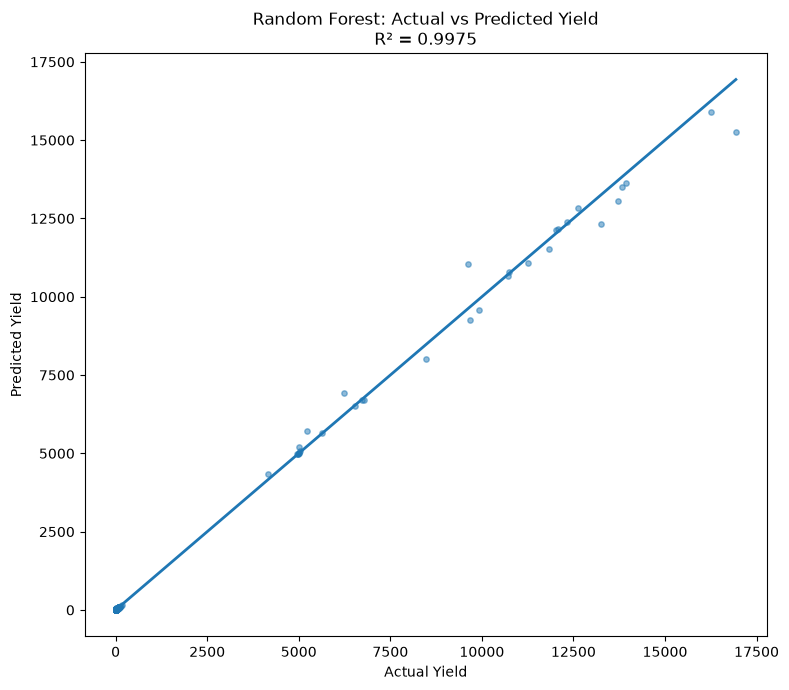

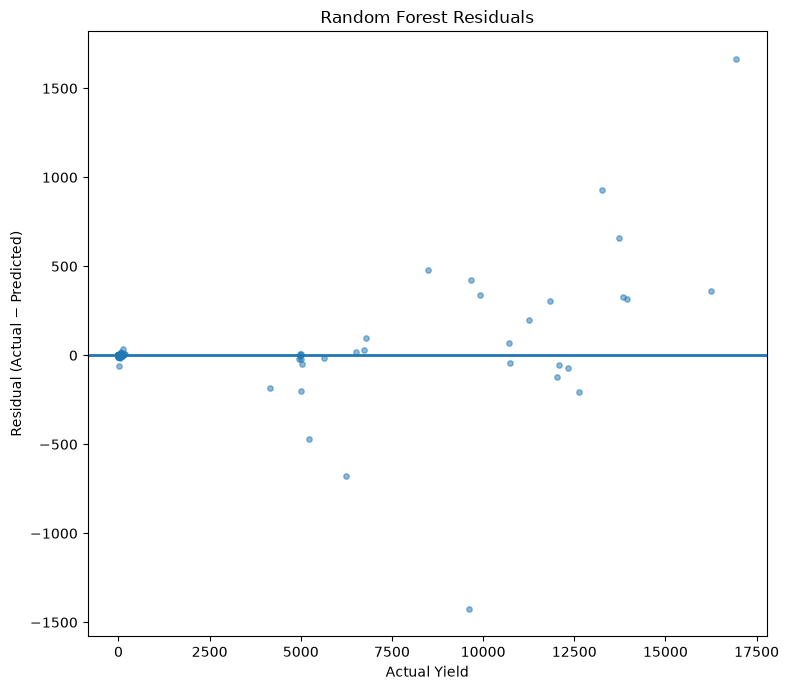

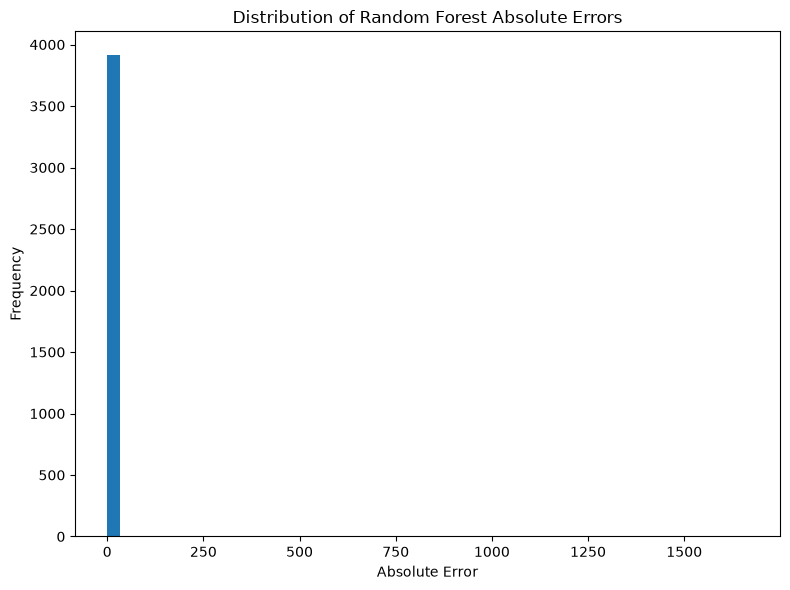

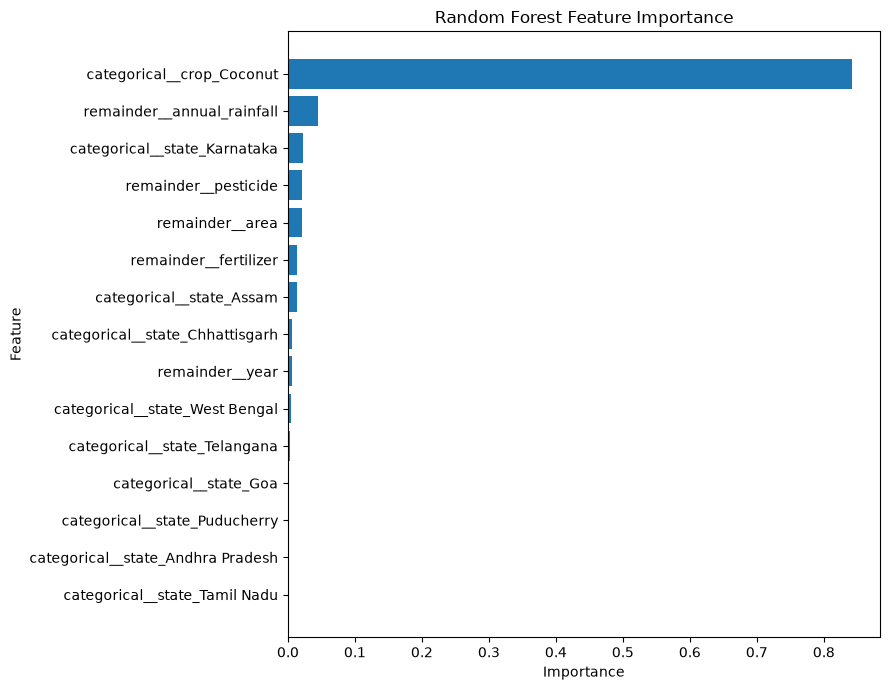


FINAL GRAPHS COMPLETE


In [98]:
# ============================================================
# FINAL MODEL RESULTS + GRAPHS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------

actual = np.asarray(y_test)
predicted = np.asarray(rf_test_pred)

residuals = actual - predicted
absolute_errors = np.abs(residuals)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
r2 = r2_score(actual, predicted)

print("=" * 75)
print("FINAL RANDOM FOREST TEST RESULTS")
print("=" * 75)

print(f"Test samples : {len(actual)}")
print(f"MAE          : {mae:.6f}")
print(f"RMSE         : {rmse:.6f}")
print(f"R²           : {r2:.6f}")


# ------------------------------------------------------------
# MODEL COMPARISON
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "95% RF + 5% Time Trend"
    ],
    "MAE": [
        2.763570,
        2.801564
    ],
    "RMSE": [
        44.942275,
        46.332409
    ],
    "R2": [
        0.997479,
        0.997321
    ]
})

print("\nMODEL COMPARISON")
print("-" * 75)
print(comparison.to_string(index=False))


# ============================================================
# GRAPH 1 — ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    actual,
    predicted,
    alpha=0.5,
    s=15
)

min_val = min(actual.min(), predicted.min())
max_val = max(actual.max(), predicted.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linewidth=2
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title(
    f"Random Forest: Actual vs Predicted Yield\n"
    f"R² = {r2:.4f}"
)

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2 — RESIDUALS VS ACTUAL
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    actual,
    residuals,
    alpha=0.5,
    s=15
)

plt.axhline(
    0,
    linewidth=2
)

plt.xlabel("Actual Yield")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Random Forest Residuals")

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 3 — ABSOLUTE ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    absolute_errors,
    bins=50
)

plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of Random Forest Absolute Errors")

plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 4 — FEATURE IMPORTANCE
# ============================================================

try:

    feature_names = preprocessor.get_feature_names_out()

    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": rf_model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    ).head(15)

    plt.figure(figsize=(9, 7))

    plt.barh(
        importance["Feature"][::-1],
        importance["Importance"][::-1]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Random Forest Feature Importance")

    plt.tight_layout()
    plt.show()

except Exception as e:

    print("\nFeature importance graph could not be generated.")
    print("Reason:", e)


print("\n" + "=" * 75)
print("FINAL GRAPHS COMPLETE")
print("=" * 75)

In [99]:
importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.to_string(index=False))

                                Feature   Importance
              categorical__crop_Coconut 8.417618e-01
             remainder__annual_rainfall 4.515414e-02
           categorical__state_Karnataka 2.294864e-02
                   remainder__pesticide 2.147879e-02
                        remainder__area 2.030294e-02
                  remainder__fertilizer 1.310382e-02
               categorical__state_Assam 1.303432e-02
        categorical__state_Chhattisgarh 6.219686e-03
                        remainder__year 6.201120e-03
         categorical__state_West Bengal 4.274873e-03
           categorical__state_Telangana 2.387783e-03
                 categorical__state_Goa 1.375714e-03
          categorical__state_Puducherry 3.771394e-04
      categorical__state_Andhra Pradesh 3.599221e-04
          categorical__state_Tamil Nadu 2.348684e-04
             categorical__state_Mizoram 2.289129e-04
         categorical__season_Whole Year 2.155888e-04
             categorical__season_Kharif 1.2600

In [100]:
# ============================================================
# SAVE FINAL RANDOM FOREST MODEL
# ============================================================

import joblib
import os

MODEL_DIR = "agri_yield_model"

os.makedirs(MODEL_DIR, exist_ok=True)

# Save preprocessing pipeline
joblib.dump(
    preprocessor,
    os.path.join(MODEL_DIR, "preprocessor.pkl")
)

# Save trained Random Forest
joblib.dump(
    rf_model,
    os.path.join(MODEL_DIR, "random_forest.pkl")
)

print("=" * 60)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 60)

print(
    "Preprocessor:",
    os.path.join(MODEL_DIR, "preprocessor.pkl")
)

print(
    "Random Forest:",
    os.path.join(MODEL_DIR, "random_forest.pkl")
)

print("\nFiles created:")
print(os.listdir(MODEL_DIR))

MODEL SAVED SUCCESSFULLY
Preprocessor: agri_yield_model\preprocessor.pkl
Random Forest: agri_yield_model\random_forest.pkl

Files created:
['preprocessor.pkl', 'random_forest.pkl']


In [101]:
# ============================================================
# VERIFY SAVED MODEL
# ============================================================

import joblib

loaded_preprocessor = joblib.load(
    "agri_yield_model/preprocessor.pkl"
)

loaded_model = joblib.load(
    "agri_yield_model/random_forest.pkl"
)

# Transform the existing unseen test data
X_test_loaded = loaded_preprocessor.transform(X_test)

# Predict
loaded_predictions = loaded_model.predict(
    X_test_loaded
)

print("=" * 60)
print("SAVED MODEL VERIFICATION")
print("=" * 60)

print("Predictions generated:", len(loaded_predictions))

print(
    "First 5 predictions:",
    loaded_predictions[:5]
)

print(
    "\nMAE:",
    mean_absolute_error(y_test, loaded_predictions)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            loaded_predictions
        )
    )
)

print(
    "R²:",
    r2_score(
        y_test,
        loaded_predictions
    )
)

SAVED MODEL VERIFICATION
Predictions generated: 3938
First 5 predictions: [3.76473333 1.40497724 6.5411569  0.80443901 0.52713571]

MAE: 2.7635698034588536
RMSE: 44.94227469035734
R²: 0.9974791468288027
